In [47]:
# Package imports, environment check, random seed
# Purpose: Verify all ML packages are installed and set global reproducibility seed.

import sys
import platform
import gc
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import psutil

# ML stack
import sklearn
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import xgboost as xgb
import optuna
import shap

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress non-critical warnings for cleaner notebook output
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Global reproducibility seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Optuna logging: keep concise during tuning
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Environment report
print("Environment check")
print(f"  Python       : {sys.version.split()[0]}")
print(f"  Platform     : {platform.platform()}")
print(f"  Processor    : {platform.processor()}")
print()
print("Package versions")
print(f"  numpy        : {np.__version__}")
print(f"  pandas       : {pd.__version__}")
print(f"  scikit-learn : {sklearn.__version__}")
print(f"  xgboost      : {xgb.__version__}")
print(f"  optuna       : {optuna.__version__}")
print(f"  shap         : {shap.__version__}")
print()

# Memory snapshot
vm = psutil.virtual_memory()
print("Memory snapshot")
print(f"  Total RAM    : {vm.total / 1e9:.2f} GB")
print(f"  Available    : {vm.available / 1e9:.2f} GB")
print(f"  Used         : {vm.used / 1e9:.2f} GB ({vm.percent:.1f}%)")
print()
print(f"RANDOM_SEED set to {RANDOM_SEED}")

Environment check
  Python       : 3.11.15
  Platform     : macOS-26.3.1-arm64-arm-64bit
  Processor    : arm

Package versions
  numpy        : 2.4.4
  pandas       : 3.0.2
  scikit-learn : 1.8.0
  xgboost      : 3.2.0
  optuna       : 4.8.0
  shap         : 0.51.0

Memory snapshot
  Total RAM    : 17.18 GB
  Available    : 4.64 GB
  Used         : 7.07 GB (73.0%)

RANDOM_SEED set to 42


In [48]:
# Load feature matrix and perform sanity checks
# Purpose: Verify 02_feature_engineering.ipynb output matches documented schema.

PROJECT_ROOT = Path.home() / "Desktop" / "PISA-Process-Data-Analysis"
FEATURES_PATH = PROJECT_ROOT / "data" / "analysis" / "pisa2022_features.parquet"

print(f"Loading: {FEATURES_PATH.name}")
df = pd.read_parquet(FEATURES_PATH)
print(f"Loaded  : shape = {df.shape}")
print()

# Expected schema from 02_feature_engineering.ipynb
EXPECTED_ROWS = 554_680
EXPECTED_COLS = 36

ID_COLS = ["CNTSTUID", "CNT", "CNTSCHID"]
TARGET_COLS = ["math_score"] + [f"PV{i}MATH" for i in range(1, 11)]
CONTEXTUAL_COLS = [
    "ESCS", "ST004D01T", "ST019AQ01T", "MISCED", "FISCED",
    "HOMEPOS", "MATHEFF", "ANXMAT", "BELONG", "EFFORTT",
]
BEHAVIORAL_COLS = [
    "log_total_time", "log_mean_time_per_item", "time_cv",
    "effort_regulation", "mean_visits_per_item", "revisit_ratio",
    "log_mean_actions", "first_visit_completion_ratio",
    "system1_probability", "rapid_guess_ratio_nt15", "log_effortt",
]
META_COLS = ["n_items_valid"]

expected_all = ID_COLS + TARGET_COLS + CONTEXTUAL_COLS + BEHAVIORAL_COLS + META_COLS

# Shape check
print("Shape check")
print(f"  Rows    : {df.shape[0]:,} (expected {EXPECTED_ROWS:,}) "
      f"{'OK' if df.shape[0] == EXPECTED_ROWS else 'MISMATCH'}")
print(f"  Columns : {df.shape[1]} (expected {EXPECTED_COLS}) "
      f"{'OK' if df.shape[1] == EXPECTED_COLS else 'MISMATCH'}")
print()

# Column presence check
missing_cols = [c for c in expected_all if c not in df.columns]
unexpected_cols = [c for c in df.columns if c not in expected_all]
print("Column presence check")
print(f"  Missing from dataframe : {missing_cols if missing_cols else 'none'}")
print(f"  Unexpected columns     : {unexpected_cols if unexpected_cols else 'none'}")
print()

# Dtypes summary
print("Dtype summary")
print(df.dtypes.value_counts().to_string())
print()

# Missing pattern recap — compare with documented rates
print("Missing pattern (key variables, expected from 02_feature_engineering.ipynb)")
expected_missing = {
    "ST004D01T": 0.0, "HOMEPOS": 2.6, "EFFORTT": 1.1, "ESCS": 4.1,
    "ST019AQ01T": 4.2, "MISCED": 5.4, "FISCED": 7.4, "BELONG": 8.5,
    "ANXMAT": 22.5, "MATHEFF": 23.5,
}
miss_check = pd.DataFrame({
    "observed_%": (df[list(expected_missing)].isna().mean() * 100).round(2),
    "expected_%": pd.Series(expected_missing),
})
miss_check["delta"] = (miss_check["observed_%"] - miss_check["expected_%"]).round(2)
print(miss_check.to_string())
print()

# Target availability check (PVs should be complete)
pv_missing = df[TARGET_COLS].isna().sum()
print("Target completeness")
print(f"  Any missing in targets : {pv_missing.sum() == 0}")
if pv_missing.sum() > 0:
    print(pv_missing[pv_missing > 0].to_string())
print()

# Country count (for stratification planning)
print(f"Number of countries (CNT): {df['CNT'].nunique()}")
print(f"Min students per country : {df['CNT'].value_counts().min():,}")
print(f"Median students per country : {int(df['CNT'].value_counts().median()):,}")

Loading: pisa2022_features.parquet
Loaded  : shape = (554680, 47)

Shape check
  Rows    : 554,680 (expected 554,680) OK
  Columns : 47 (expected 36) MISMATCH

Column presence check
  Missing from dataframe : none
  Unexpected columns     : ['W_FSTUWT', 'log_mean_time_per_item_raw', 'time_cv_raw', 'effort_regulation_raw', 'guessing_ratio', 'heuristic_ratio', 'n_paired_items_valid', 'adaptive_sample', 'n_items_seen', 'n_cm_items_valid', 'n_cma_items_valid']

Dtype summary
float32    38
int16       4
int64       2
str         1
int32       1
int8        1

Missing pattern (key variables, expected from 02_feature_engineering.ipynb)
            observed_%  expected_%  delta
ST004D01T         0.01         0.0   0.01
HOMEPOS           2.60         2.6   0.00
EFFORTT           1.06         1.1  -0.04
ESCS              4.24         4.1   0.14
ST019AQ01T        4.13         4.2  -0.07
MISCED            5.51         5.4   0.11
FISCED            7.46         7.4   0.06
BELONG            8.59     

In [49]:
# float32 optimization for numeric features, memory report
# Purpose: Reduce memory footprint for 8 GB RAM constraint without affecting model fidelity.
# Strategy: Convert float64 columns to float32; keep IDs, categoricals, and integer columns intact.

def report_memory(df, label):
    mem_mb = df.memory_usage(deep=True).sum() / 1e6
    print(f"  {label:<20s} : {mem_mb:8.2f} MB")
    return mem_mb

# Columns that MUST NOT be cast to float32
PROTECTED_COLS = set(ID_COLS) | {"ST004D01T", "ST019AQ01T"}

# Identify float64 columns eligible for downcast
float64_cols = [
    c for c in df.columns
    if df[c].dtype == "float64" and c not in PROTECTED_COLS
]

print(f"float64 columns eligible for downcast: {len(float64_cols)}")
print(f"  -> {float64_cols}")
print()

# Memory before
print("Memory usage")
mem_before = report_memory(df, "before downcast")

# Cast to float32
for col in float64_cols:
    df[col] = df[col].astype(np.float32)

# Memory after
mem_after = report_memory(df, "after downcast")
print(f"  {'savings':<20s} : {mem_before - mem_after:8.2f} MB "
      f"({(1 - mem_after / mem_before) * 100:.1f}%)")
print()

# Final dtype summary
print("Final dtype summary")
print(df.dtypes.value_counts().to_string())
print()

# Spot-check a few casts to confirm value integrity
spot_cols = ["ESCS", "system1_probability", "log_total_time", "PV1MATH"]
spot_cols = [c for c in spot_cols if c in df.columns]
print("Post-cast value sanity (spot check)")
print(df[spot_cols].describe().round(4).to_string())
print()

# System memory snapshot
vm = psutil.virtual_memory()
print("System memory snapshot")
print(f"  Available RAM : {vm.available / 1e9:.2f} GB ({100 - vm.percent:.1f}% free)")

gc.collect()

float64 columns eligible for downcast: 0
  -> []

Memory usage
  before downcast      :   106.50 MB
  after downcast       :   106.50 MB
  savings              :     0.00 MB (0.0%)

Final dtype summary
float32    38
int16       4
int64       2
str         1
int32       1
int8        1

Post-cast value sanity (spot check)
              ESCS  system1_probability  log_total_time      PV1MATH
count  531186.0000          554680.0000     554680.0000  554680.0000
mean       -0.2626               0.2089         14.6751     443.4616
std         1.0960               0.1759          0.4601     101.1100
min        -6.8407               0.0115         10.0356      99.7080
25%        -0.9938               0.0890         14.5293     367.0857
50%        -0.1421               0.1442         14.8174     435.6930
75%         0.6088               0.2640         14.9705     513.4530
max         7.3800               1.0000         16.2531     943.0410

System memory snapshot
  Available RAM : 4.57 GB (26.6%

7526

In [50]:
# Feature categorization
# Purpose: Explicitly partition columns into ID/metadata, targets, contextual, and behavioral groups.
# This partition drives all downstream encoding, modeling, and SHAP group-level analysis.

# Identifiers (not model inputs; CNTSCHID held out for potential school-level analysis)
ID_COLS = ["CNTSTUID", "CNT", "CNTSCHID"]

# Targets: hybrid PV strategy (math_score = single baseline, PV1-10 = Rubin's Rules)
TARGET_COLS = ["math_score"] + [f"PV{i}MATH" for i in range(1, 11)]

# Contextual features (student background + affective-motivational)
CONTEXTUAL_COLS = [
    "ESCS", "ST004D01T", "ST019AQ01T", "MISCED", "FISCED",
    "HOMEPOS", "MATHEFF", "ANXMAT", "BELONG", "EFFORTT",
]

# Behavioral features (engineered from process data; Dual-Process Theory operationalization)
BEHAVIORAL_COLS = [
    "log_total_time", "log_mean_time_per_item", "time_cv",
    "effort_regulation", "mean_visits_per_item", "revisit_ratio",
    "log_mean_actions", "first_visit_completion_ratio",
    "system1_probability", "rapid_guess_ratio_nt15", "log_effortt",
]

# Metadata columns: kept in dataframe for sensitivity/diagnostic analyses but NOT in X
METADATA_COLS = [
    "W_FSTUWT",                    # Survey weight -> weighted sensitivity analysis
    "adaptive_sample",             # Adaptive testing flag
    "n_items_valid",               # Sample quality
    "n_items_seen",
    "n_paired_items_valid",
    "n_cm_items_valid",
    "n_cma_items_valid",
    "log_mean_time_per_item_raw",  # Pre-winsorization diagnostics
    "time_cv_raw",
    "effort_regulation_raw",
]

# Excluded: plan-external behavioral indicators
EXCLUDED_COLS = ["guessing_ratio", "heuristic_ratio"]

# Verify every column is accounted for
all_categorized = set(ID_COLS + TARGET_COLS + CONTEXTUAL_COLS +
                      BEHAVIORAL_COLS + METADATA_COLS + EXCLUDED_COLS)
all_actual = set(df.columns)

missing_from_categorization = all_actual - all_categorized
extra_in_categorization = all_categorized - all_actual

print("Categorization integrity check")
print(f"  Uncategorized columns in df : {missing_from_categorization if missing_from_categorization else 'none'}")
print(f"  Categorized but not in df   : {extra_in_categorization if extra_in_categorization else 'none'}")
print()

# Summary table
summary = pd.DataFrame({
    "category": (
        ["ID"] * len(ID_COLS) +
        ["target"] * len(TARGET_COLS) +
        ["contextual"] * len(CONTEXTUAL_COLS) +
        ["behavioral"] * len(BEHAVIORAL_COLS) +
        ["metadata"] * len(METADATA_COLS) +
        ["excluded"] * len(EXCLUDED_COLS)
    ),
    "column": (
        ID_COLS + TARGET_COLS + CONTEXTUAL_COLS +
        BEHAVIORAL_COLS + METADATA_COLS + EXCLUDED_COLS
    ),
})
print("Column counts by category")
print(summary["category"].value_counts().to_string())
print()

# Store a metadata frame separately for later use (weighted sensitivity, diagnostics)
df_metadata = df[ID_COLS + METADATA_COLS].copy()
print(f"Metadata frame stored: shape = {df_metadata.shape}")
print(f"  Columns: {list(df_metadata.columns)}")

Categorization integrity check
  Uncategorized columns in df : none
  Categorized but not in df   : none

Column counts by category
category
target        11
behavioral    11
contextual    10
metadata      10
ID             3
excluded       2

Metadata frame stored: shape = (554680, 13)
  Columns: ['CNTSTUID', 'CNT', 'CNTSCHID', 'W_FSTUWT', 'adaptive_sample', 'n_items_valid', 'n_items_seen', 'n_paired_items_valid', 'n_cm_items_valid', 'n_cma_items_valid', 'log_mean_time_per_item_raw', 'time_cv_raw', 'effort_regulation_raw']


In [51]:
# Missing indicator creation for variables with >= 5% missingness
# Purpose: Capture potential MNAR signal; missingness pattern itself may be informative.
# Reference: Groenwold (2020); Sperrin et al. (2020) on missing indicator approach in ML.

# Variables flagged for missing indicators (threshold: >= 5% per 02_feature_engineering.ipynb report)
MISSING_INDICATOR_VARS = ["MATHEFF", "ANXMAT", "BELONG", "FISCED", "MISCED"]

print("Creating missing indicators")
print(f"{'variable':<12s} {'miss_%':>8s} {'indicator_col':<25s}")

missing_indicator_cols = []
for col in MISSING_INDICATOR_VARS:
    miss_pct = df[col].isna().mean() * 100
    indicator_col = f"{col}_missing"
    df[indicator_col] = df[col].isna().astype(np.int8)
    missing_indicator_cols.append(indicator_col)
    print(f"{col:<12s} {miss_pct:>7.2f}% {indicator_col:<25s}")

print()
print(f"Created {len(missing_indicator_cols)} missing indicator columns")

# Sanity: verify indicators are 0/1 and sums match NaN counts
print()
print("Indicator integrity check")
for orig, ind in zip(MISSING_INDICATOR_VARS, missing_indicator_cols):
    orig_nan = df[orig].isna().sum()
    ind_sum = df[ind].sum()
    status = "OK" if orig_nan == ind_sum else "MISMATCH"
    print(f"  {orig}: NaN={orig_nan:,}, indicator_sum={ind_sum:,} [{status}]")

Creating missing indicators
variable       miss_% indicator_col            
MATHEFF        23.62% MATHEFF_missing          
ANXMAT         22.49% ANXMAT_missing           
BELONG          8.59% BELONG_missing           
FISCED          7.46% FISCED_missing           
MISCED          5.51% MISCED_missing           

Created 5 missing indicator columns

Indicator integrity check
  MATHEFF: NaN=131,031, indicator_sum=131,031 [OK]
  ANXMAT: NaN=124,774, indicator_sum=124,774 [OK]
  BELONG: NaN=47,670, indicator_sum=47,670 [OK]
  FISCED: NaN=41,371, indicator_sum=41,371 [OK]
  MISCED: NaN=30,586, indicator_sum=30,586 [OK]


In [52]:
# Categorical encoding
# Purpose: Apply encoding strategies matched to each variable's measurement scale.
# - CNT (76 countries, nominal): sparse one-hot
# - Binary categoricals (gender, immigrant status): label encoding
# - Ordinal (parental education ISCED): verify existing integer representation

from scipy.sparse import csr_matrix, hstack as sparse_hstack
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# --- CNT: sparse one-hot ---
print("Encoding CNT (country) as sparse one-hot")
cnt_encoder = OneHotEncoder(sparse_output=True, handle_unknown="ignore", dtype=np.float32)
cnt_sparse = cnt_encoder.fit_transform(df[["CNT"]])
cnt_feature_names = [f"CNT_{c}" for c in cnt_encoder.categories_[0]]
print(f"CNT one-hot shape: {cnt_sparse.shape}")
print(f"Sparsity         : {1 - cnt_sparse.nnz / (cnt_sparse.shape[0] * cnt_sparse.shape[1]):.4f}")
print()

# --- Binary categoricals: label encoding ---
print("Label encoding binary categoricals")
BINARY_CATEGORICALS = ["ST004D01T", "ST019AQ01T"]
binary_encoders = {}
for col in BINARY_CATEGORICALS:
    le = LabelEncoder()
    # Handle NaN: encode non-null values, keep NaN as NaN (XGBoost will handle)
    mask = df[col].notna()
    df[f"{col}_enc"] = np.nan
    df.loc[mask, f"{col}_enc"] = le.fit_transform(df.loc[mask, col].astype(str))
    df[f"{col}_enc"] = df[f"{col}_enc"].astype(np.float32)
    binary_encoders[col] = le
    print(f"  {col:<12s} unique values: {list(le.classes_)} -> {list(range(len(le.classes_)))}")
print()

# --- Ordinal: verify MISCED, FISCED ---
print("Verifying ordinal encoding for MISCED, FISCED")
for col in ["MISCED", "FISCED"]:
    unique_vals = sorted(df[col].dropna().unique())
    dtype = df[col].dtype
    print(f"  {col:<8s} dtype={dtype}, unique values={unique_vals}")
print()
print("  -> Both columns are already integer-coded ISCED levels; no transformation needed.")

Encoding CNT (country) as sparse one-hot
CNT one-hot shape: (554680, 76)
Sparsity         : 0.9868

Label encoding binary categoricals
  ST004D01T    unique values: ['1.0', '2.0'] -> [0, 1]
  ST019AQ01T   unique values: ['1.0', '2.0', '3.0'] -> [0, 1, 2]

Verifying ordinal encoding for MISCED, FISCED
  MISCED   dtype=float32, unique values=[np.float32(1.0), np.float32(2.0), np.float32(3.0), np.float32(4.0), np.float32(5.0), np.float32(6.0), np.float32(7.0), np.float32(8.0), np.float32(9.0), np.float32(10.0)]
  FISCED   dtype=float32, unique values=[np.float32(1.0), np.float32(2.0), np.float32(3.0), np.float32(4.0), np.float32(5.0), np.float32(6.0), np.float32(7.0), np.float32(8.0), np.float32(9.0), np.float32(10.0)]

  -> Both columns are already integer-coded ISCED levels; no transformation needed.


In [53]:
# Final X, y matrices + design matrix summary
# Purpose: Assemble the final design matrix (sparse) and target matrix for modeling.

# Dense feature columns to include (after encoding)
DENSE_FEATURE_COLS = (
    # Contextual, non-categorical
    ["ESCS", "MISCED", "FISCED", "HOMEPOS", "MATHEFF", "ANXMAT", "BELONG", "EFFORTT"]
    # Encoded binary categoricals
    + ["ST004D01T_enc", "ST019AQ01T_enc"]
    # Behavioral
    + BEHAVIORAL_COLS
    # Missing indicators
    + missing_indicator_cols
)

print(f"Dense feature columns ({len(DENSE_FEATURE_COLS)}):")
print(f"{DENSE_FEATURE_COLS}")
print()

# Build dense feature matrix and convert to sparse
X_dense = df[DENSE_FEATURE_COLS].astype(np.float32).values
X_dense_sparse = csr_matrix(X_dense)
print(f"Dense block shape: {X_dense_sparse.shape}")
print(f"CNT block shape  : {cnt_sparse.shape}")

# Horizontal stack: [dense features | CNT one-hot]
X = sparse_hstack([X_dense_sparse, cnt_sparse], format="csr")
feature_names = DENSE_FEATURE_COLS + cnt_feature_names

print(f"Final X shape    : {X.shape}")
print(f"Feature count    : {len(feature_names)}")
print(f"X memory (sparse): {(X.data.nbytes + X.indices.nbytes + X.indptr.nbytes) / 1e6:.2f} MB")
print()

# Targets: hybrid strategy
y_single = df["math_score"].astype(np.float32).values
Y_pvs = df[[f"PV{i}MATH" for i in range(1, 11)]].astype(np.float32).values
print(f"y_single (math_score) shape: {y_single.shape}")
print(f"Y_pvs (10 PVs) shape       : {Y_pvs.shape}")
print()

# Keep student/country IDs aligned for stratification and saving
ids = df[ID_COLS].copy()
print(f"IDs frame shape: {ids.shape}")
print()

# Design matrix summary
print("Design matrix summary")
print(f"Total observations: {X.shape[0]:,}")
print(f"Total features    : {X.shape[1]} ({len(DENSE_FEATURE_COLS)} dense + {cnt_sparse.shape[1]} country dummies)")
print(f"Targets           : 1 single (math_score) + 10 PVs")
print(f"Sparsity          : {1 - X.nnz / (X.shape[0] * X.shape[1]):.4f}")
print()

# Feature group mapping (for SHAP group analysis later)
feature_groups = {
    "contextual": (
        ["ESCS", "MISCED", "FISCED", "HOMEPOS", "MATHEFF",
         "ANXMAT", "BELONG", "EFFORTT", "ST004D01T_enc", "ST019AQ01T_enc"]
    ),
    "behavioral": BEHAVIORAL_COLS,
    "missing_indicators": missing_indicator_cols,
    "country": cnt_feature_names,
}
print("Feature groups (for SHAP group analysis)")
for g, cols in feature_groups.items():
    print(f"{g:<20s} : {len(cols)} features")

# Memory cleanup
del X_dense, X_dense_sparse
gc.collect()

vm = psutil.virtual_memory()
print()
print(f"System memory: available = {vm.available / 1e9:.2f} GB")

Dense feature columns (26):
['ESCS', 'MISCED', 'FISCED', 'HOMEPOS', 'MATHEFF', 'ANXMAT', 'BELONG', 'EFFORTT', 'ST004D01T_enc', 'ST019AQ01T_enc', 'log_total_time', 'log_mean_time_per_item', 'time_cv', 'effort_regulation', 'mean_visits_per_item', 'revisit_ratio', 'log_mean_actions', 'first_visit_completion_ratio', 'system1_probability', 'rapid_guess_ratio_nt15', 'log_effortt', 'MATHEFF_missing', 'ANXMAT_missing', 'BELONG_missing', 'FISCED_missing', 'MISCED_missing']

Dense block shape: (554680, 26)
CNT block shape  : (554680, 76)
Final X shape    : (554680, 102)
Feature count    : 102
X memory (sparse): 92.63 MB

y_single (math_score) shape: (554680,)
Y_pvs (10 PVs) shape       : (554680, 10)

IDs frame shape: (554680, 3)

Design matrix summary
Total observations: 554,680
Total features    : 102 (26 dense + 76 country dummies)
Targets           : 1 single (math_score) + 10 PVs
Sparsity          : 0.8002

Feature groups (for SHAP group analysis)
contextual           : 10 features
behavior

In [54]:
# Country-stratified 80/20 train/test split
# Purpose: Hold-out test set, stratified by country to preserve cross-national representativeness.
# Rationale:
# - PISA spans 76 countries with vastly different score distributions (e.g., Singapore ~575, Philippines ~355);
#   random split risks country-level imbalance.
# - Hold-out set isolates final performance reporting from hyperparameter tuning, preventing
#   optimistic bias (Cawley & Talbot, 2010).
# - Tuning will use k=5 country-stratified CV on the TRAIN set only (Cell 14 onward).

from sklearn.model_selection import train_test_split

# Stratification variable: CNT (country)
strata = df["CNT"].values

# Split indices (stratified)
train_idx, test_idx = train_test_split(
    np.arange(X.shape[0]),
    test_size=0.20,
    stratify=strata,
    random_state=RANDOM_SEED,
)

# Apply split to X (sparse), y_single, Y_pvs, and ids
X_train = X[train_idx]
X_test = X[test_idx]

y_single_train = y_single[train_idx]
y_single_test = y_single[test_idx]

Y_pvs_train = Y_pvs[train_idx]
Y_pvs_test = Y_pvs[test_idx]

ids_train = ids.iloc[train_idx].reset_index(drop=True)
ids_test = ids.iloc[test_idx].reset_index(drop=True)

# Metadata split (for weighted sensitivity analysis in Cell 22)
meta_train = df_metadata.iloc[train_idx].reset_index(drop=True)
meta_test = df_metadata.iloc[test_idx].reset_index(drop=True)

print("Split sizes")
print(f"Train: {X_train.shape[0]:,} ({X_train.shape[0] / X.shape[0] * 100:.1f}%)")
print(f"Test : {X_test.shape[0]:,} ({X_test.shape[0] / X.shape[0] * 100:.1f}%)")
print()

# Stratification verification: country proportions in train vs test
print("Stratification verification (country proportions)")
train_props = ids_train["CNT"].value_counts(normalize=True).sort_index()
test_props = ids_test["CNT"].value_counts(normalize=True).sort_index()
strat_check = pd.DataFrame({
    "train_%": (train_props * 100).round(3),
    "test_%": (test_props * 100).round(3),
})
strat_check["abs_diff"] = (strat_check["train_%"] - strat_check["test_%"]).abs().round(3)

print(f"Max absolute proportion difference : {strat_check['abs_diff'].max():.4f}%")
print(f"Mean absolute proportion difference: {strat_check['abs_diff'].mean():.4f}%")
print(f"Countries in train: {train_props.shape[0]}")
print(f"Countries in test : {test_props.shape[0]}")
print()

# Target distribution check: PV1MATH mean/std in train vs test
pv1_train_mean = Y_pvs_train[:, 0].mean()
pv1_train_std = Y_pvs_train[:, 0].std()
pv1_test_mean = Y_pvs_test[:, 0].mean()
pv1_test_std = Y_pvs_test[:, 0].std()

print("Target distribution check (PV1MATH)")
print(f"Train: mean = {pv1_train_mean:7.2f}, std = {pv1_train_std:6.2f}")
print(f"Test : mean = {pv1_test_mean:7.2f}, std = {pv1_test_std:6.2f}")
print()

# Memory cleanup: release full X (we now work with X_train/X_test)
del X
gc.collect()

vm = psutil.virtual_memory()
print(f"System memory after cleanup: available = {vm.available / 1e9:.2f} GB")

Split sizes
Train: 443,744 (80.0%)
Test : 110,936 (20.0%)

Stratification verification (country proportions)
Max absolute proportion difference : 0.0010%
Mean absolute proportion difference: 0.0002%
Countries in train: 76
Countries in test : 76

Target distribution check (PV1MATH)
Train: mean =  443.48, std = 101.12
Test : mean =  443.40, std = 101.07

System memory after cleanup: available = 4.48 GB


In [55]:
# : Ridge regression function with IterativeImputer (MICE)
# Purpose: Fit Ridge on each PV separately, using MICE-based imputation for missing values.
# Key design:
#   - IterativeImputer applied ONLY to dense features (CNT dummies have no NaN).
#   - Fit on train, transform on test (prevents data leakage).
#   - BayesianRidge estimator (standard for MICE in educational research).
#   - n_nearest_features=10 for tractable runtime on 443k samples.
#   - sample_posterior=False: single imputation (10 PV already handles imputation uncertainty).
# Reference: Van Buuren (2018), Azur et al. (2011) on MICE for educational data.

# Enable experimental IterativeImputer
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from scipy.sparse import issparse, csr_matrix, hstack as sparse_hstack

# Identify dense vs CNT column ranges in our X matrix
# Recall: X = [dense_features (26 cols) | CNT one-hot (76 cols)]
N_DENSE_FEATURES = len(DENSE_FEATURE_COLS)
N_CNT_FEATURES = len(cnt_feature_names)

print(f"X structure: {N_DENSE_FEATURES} dense features + {N_CNT_FEATURES} CNT dummies")
print(f"IterativeImputer will be applied only to dense features (CNT dummies are complete).")
print()


def fit_ridge_on_pvs_with_mice(X_train, X_test, Y_pvs_train, Y_pvs_test,
                                alpha=1.0, random_state=RANDOM_SEED,
                                n_nearest_features=10, max_iter=10, verbose=True):
    """
    Fit Ridge on 10 PVs using IterativeImputer (MICE) for missing values.
    
    Missing values are imputed using MICE on dense features only.
    CNT one-hot dummies (no missing) are preserved as-is.
    Imputer is fit ONCE on training data and reused for all PVs (data structure
    is identical across PVs; only the target changes).
    """
    # Step 1: Separate dense block from CNT block
    if issparse(X_train):
        X_train_dense = X_train[:, :N_DENSE_FEATURES].toarray().astype(np.float32)
        X_train_cnt = X_train[:, N_DENSE_FEATURES:]
        X_test_dense = X_test[:, :N_DENSE_FEATURES].toarray().astype(np.float32)
        X_test_cnt = X_test[:, N_DENSE_FEATURES:]
    else:
        X_train_dense = X_train[:, :N_DENSE_FEATURES].astype(np.float32)
        X_train_cnt = csr_matrix(X_train[:, N_DENSE_FEATURES:])
        X_test_dense = X_test[:, :N_DENSE_FEATURES].astype(np.float32)
        X_test_cnt = csr_matrix(X_test[:, N_DENSE_FEATURES:])
    
    # Step 2: Fit IterativeImputer on train (dense block only)
    if verbose:
        n_missing_train = np.isnan(X_train_dense).sum()
        print(f"Dense train block shape : {X_train_dense.shape}")
        print(f"Missing cells in train  : {n_missing_train:,} "
              f"({n_missing_train / X_train_dense.size * 100:.2f}%)")
        print(f"Fitting IterativeImputer (MICE)...")
    
    t_imp_start = time.time()
    imputer = IterativeImputer(
        estimator=BayesianRidge(),
        max_iter=max_iter,
        n_nearest_features=n_nearest_features,
        initial_strategy="median",
        sample_posterior=False,
        random_state=random_state,
        verbose=0,
    )
    X_train_dense_imp = imputer.fit_transform(X_train_dense).astype(np.float32)
    X_test_dense_imp = imputer.transform(X_test_dense).astype(np.float32)
    t_imp_elapsed = time.time() - t_imp_start
    
    if verbose:
        print(f"Imputation completed in {t_imp_elapsed:.1f} seconds")
        print(f"Any remaining NaN in train: {np.isnan(X_train_dense_imp).sum()}")
        print(f"Any remaining NaN in test : {np.isnan(X_test_dense_imp).sum()}")
        print()
    
    # Step 3: Recombine imputed dense + CNT (sparse)
    X_train_full = sparse_hstack(
        [csr_matrix(X_train_dense_imp), X_train_cnt], format="csr"
    )
    X_test_full = sparse_hstack(
        [csr_matrix(X_test_dense_imp), X_test_cnt], format="csr"
    )
    
    # Free intermediate arrays
    del X_train_dense, X_train_dense_imp, X_test_dense, X_test_dense_imp
    gc.collect()
    
    # Step 4: Fit Ridge on each PV
    n_pvs = Y_pvs_train.shape[1]
    models = []
    predictions_train = np.zeros_like(Y_pvs_train, dtype=np.float32)
    predictions_test = np.zeros_like(Y_pvs_test, dtype=np.float32)
    metrics = []
    
    if verbose:
        print(f"Fitting Ridge (alpha={alpha}) on {n_pvs} PVs")
        print(f"  {'PV':<6s} {'train_R2':>10s} {'test_R2':>10s} "
              f"{'train_RMSE':>12s} {'test_RMSE':>12s} {'test_MAE':>10s}")
    
    for pv_idx in range(n_pvs):
        y_tr = Y_pvs_train[:, pv_idx]
        y_te = Y_pvs_test[:, pv_idx]
        
        pipe = Pipeline([
            ("scaler", StandardScaler(with_mean=False)),
            ("ridge", Ridge(alpha=alpha, random_state=random_state)),
        ])
        pipe.fit(X_train_full, y_tr)
        
        yhat_tr = pipe.predict(X_train_full).astype(np.float32)
        yhat_te = pipe.predict(X_test_full).astype(np.float32)
        predictions_train[:, pv_idx] = yhat_tr
        predictions_test[:, pv_idx] = yhat_te
        
        train_r2 = r2_score(y_tr, yhat_tr)
        test_r2 = r2_score(y_te, yhat_te)
        train_rmse = np.sqrt(mean_squared_error(y_tr, yhat_tr))
        test_rmse = np.sqrt(mean_squared_error(y_te, yhat_te))
        test_mae = mean_absolute_error(y_te, yhat_te)
        
        metrics.append({
            "pv": f"PV{pv_idx + 1}MATH",
            "train_R2": train_r2,
            "test_R2": test_r2,
            "train_RMSE": train_rmse,
            "test_RMSE": test_rmse,
            "test_MAE": test_mae,
        })
        models.append(pipe)
        
        if verbose:
            print(f"  PV{pv_idx + 1:<4d} {train_r2:>10.4f} {test_r2:>10.4f} "
                  f"{train_rmse:>12.2f} {test_rmse:>12.2f} {test_mae:>10.2f}")
    
    return {
        "models": models,
        "imputer": imputer,
        "metrics_per_pv": pd.DataFrame(metrics),
        "predictions_train": predictions_train,
        "predictions_test": predictions_test,
        "X_train_imputed": X_train_full,  # Reused for subsequent Ridge analyses if needed
        "X_test_imputed": X_test_full,
    }


print("Ridge + MICE function defined.")
print(f"  Imputation: IterativeImputer(BayesianRidge, max_iter=10, n_nearest_features=10)")
print(f"  Applied only to dense features (CNT dummies complete)")
print(f"  Scaler: StandardScaler(with_mean=False) for sparse compatibility")

X structure: 26 dense features + 76 CNT dummies
IterativeImputer will be applied only to dense features (CNT dummies are complete).

Ridge + MICE function defined.
  Imputation: IterativeImputer(BayesianRidge, max_iter=10, n_nearest_features=10)
  Applied only to dense features (CNT dummies complete)
  Scaler: StandardScaler(with_mean=False) for sparse compatibility


In [56]:
# Fit Ridge+MICE on 10 PVs + Rubin's Rules pooling

def rubins_rules_pool(estimates, variances=None, M=10):
    """Apply Rubin's Rules to pool M estimates. See Rubin (1987); Little & Rubin (2019)."""
    Q_bar = estimates.mean()
    B = estimates.var(ddof=1)
    
    if variances is not None:
        U_bar = variances.mean()
        T = U_bar + (1 + 1 / M) * B
    else:
        U_bar = np.nan
        T = (1 + 1 / M) * B
    
    SE = np.sqrt(T)
    
    if variances is not None and U_bar > 0:
        dof = (M - 1) * (1 + U_bar / ((1 + 1 / M) * B)) ** 2
    else:
        dof = M - 1
    
    from scipy.stats import t
    t_crit = t.ppf(0.975, dof)
    ci_lower = Q_bar - t_crit * SE
    ci_upper = Q_bar + t_crit * SE
    
    return {
        "estimate": Q_bar,
        "within_var": U_bar,
        "between_var": B,
        "total_var": T,
        "SE": SE,
        "dof": dof,
        "CI_lower": ci_lower,
        "CI_upper": ci_upper,
    }


print("Starting Ridge + MICE on 10 PVs...")
print("This will take 10-20 minutes; MICE imputation is the slow step, then Ridge is fast.")
print()

t_start = time.time()

ridge_results = fit_ridge_on_pvs_with_mice(
    X_train=X_train,
    X_test=X_test,
    Y_pvs_train=Y_pvs_train,
    Y_pvs_test=Y_pvs_test,
    alpha=1.0,
    n_nearest_features=10,
    max_iter=10,
)

t_elapsed = time.time() - t_start
print()
print(f"Total elapsed time: {t_elapsed / 60:.1f} minutes")
print()

# Apply Rubin's Rules
metrics_df = ridge_results["metrics_per_pv"]
pooled_results = {}
for metric in ["test_R2", "test_RMSE", "test_MAE"]:
    vals = metrics_df[metric].values
    pooled = rubins_rules_pool(vals)
    pooled_results[metric] = pooled

vm = psutil.virtual_memory()
print(f"System memory: available = {vm.available / 1e9:.2f} GB")

Starting Ridge + MICE on 10 PVs...
This will take 10-20 minutes; MICE imputation is the slow step, then Ridge is fast.

Dense train block shape : (443744, 26)
Missing cells in train  : 358,612 (3.11%)
Fitting IterativeImputer (MICE)...
Imputation completed in 7.4 seconds
Any remaining NaN in train: 0
Any remaining NaN in test : 0

Fitting Ridge (alpha=1.0) on 10 PVs
  PV       train_R2    test_R2   train_RMSE    test_RMSE   test_MAE
  PV1        0.6447     0.6450        60.28        60.22      47.57
  PV2        0.6441     0.6442        60.26        60.36      47.66
  PV3        0.6438     0.6450        60.35        60.19      47.58
  PV4        0.6445     0.6448        60.30        60.24      47.64
  PV5        0.6437     0.6436        60.37        60.40      47.76
  PV6        0.6436     0.6449        60.31        60.25      47.63
  PV7        0.6449     0.6458        60.25        60.19      47.55
  PV8        0.6444     0.6449        60.26        60.32      47.68
  PV9        0.6445

In [57]:
# Ridge results report
# Purpose: Present Ridge baseline results in a publication-ready format.

print("Ridge Regression Baseline — Per-PV Results")
print()
print(metrics_df.round(4).to_string(index=False))
print()

print("Ridge Regression Baseline — Rubin's Rules Pooled Estimates")
print()
report = pd.DataFrame({
    "metric": ["test_R2", "test_RMSE", "test_MAE"],
    "pooled_estimate": [pooled_results[m]["estimate"] for m in ["test_R2", "test_RMSE", "test_MAE"]],
    "between_var": [pooled_results[m]["between_var"] for m in ["test_R2", "test_RMSE", "test_MAE"]],
    "SE": [pooled_results[m]["SE"] for m in ["test_R2", "test_RMSE", "test_MAE"]],
    "CI_95_lower": [pooled_results[m]["CI_lower"] for m in ["test_R2", "test_RMSE", "test_MAE"]],
    "CI_95_upper": [pooled_results[m]["CI_upper"] for m in ["test_R2", "test_RMSE", "test_MAE"]],
})
print(report.round(4).to_string(index=False))
print()

# Summary statement
r2_pooled = pooled_results["test_R2"]["estimate"]
r2_ci_low = pooled_results["test_R2"]["CI_lower"]
r2_ci_up = pooled_results["test_R2"]["CI_upper"]
rmse_pooled = pooled_results["test_RMSE"]["estimate"]

print("Baseline summary")
print(f"Ridge (alpha=1.0) on {X_train.shape[1]} features, 10 PVs:")
print(f"Pooled test R² = {r2_pooled:.4f} [95% CI: {r2_ci_low:.4f}, {r2_ci_up:.4f}]")
print(f"Pooled test RMSE = {rmse_pooled:.2f}")
print()
print("This is the linear baseline against which XGBoost's non-linear gains will be evaluated.")

Ridge Regression Baseline — Per-PV Results

      pv  train_R2  test_R2  train_RMSE  test_RMSE  test_MAE
 PV1MATH    0.6447   0.6450     60.2755    60.2172   47.5675
 PV2MATH    0.6441   0.6442     60.2639    60.3591   47.6640
 PV3MATH    0.6438   0.6450     60.3503    60.1918   47.5796
 PV4MATH    0.6445   0.6448     60.2972    60.2450   47.6435
 PV5MATH    0.6437   0.6436     60.3686    60.4018   47.7619
 PV6MATH    0.6436   0.6449     60.3093    60.2521   47.6308
 PV7MATH    0.6449   0.6458     60.2525    60.1904   47.5549
 PV8MATH    0.6444   0.6449     60.2575    60.3201   47.6810
 PV9MATH    0.6445   0.6462     60.2596    60.1203   47.5700
PV10MATH    0.6447   0.6451     60.2011    60.1896   47.5639

Ridge Regression Baseline — Rubin's Rules Pooled Estimates

   metric  pooled_estimate  between_var     SE  CI_95_lower  CI_95_upper
  test_R2           0.6450       0.0000 0.0008       0.6433       0.6467
test_RMSE          60.2487       0.0076 0.0914      60.0420      60.4555
 test

In [58]:
# XGBoost baseline with default hyperparameters on PV1MATH
# Purpose: Quick sanity check before hyperparameter tuning.
# Rationale: If default XGBoost already beats Ridge meaningfully, the non-linear hypothesis
# is supported and tuning will likely yield further gains. PV1MATH chosen for consistency 
# with Optuna tuning which will also use PV1MATH.

print("XGBoost baseline: default hyperparameters on PV1MATH")
print()

# Default XGBoost — minimal configuration, no tuning
xgb_default = xgb.XGBRegressor(
    n_estimators=500,
    tree_method="hist",           # Fast histogram-based algorithm
    enable_categorical=False,     # We pre-encoded categoricals
    random_state=RANDOM_SEED,
    n_jobs=-1,                    # Use all cores
    verbosity=0,
)

print("Model configuration")
print(f"  n_estimators : 500")
print(f"  tree_method  : hist")
print(f"  Other params : DEFAULTS (learning_rate=0.3, max_depth=6, etc.)")
print()
print("Note: XGBoost handles NaN natively, so raw X_train is used (no imputation).")
print()

t_start = time.time()
xgb_default.fit(X_train, Y_pvs_train[:, 0])
t_elapsed = time.time() - t_start
print(f"Training completed in {t_elapsed:.1f} seconds")
print()

# Evaluate on train and test
yhat_train_xgb = xgb_default.predict(X_train)
yhat_test_xgb = xgb_default.predict(X_test)

xgb_train_r2 = r2_score(Y_pvs_train[:, 0], yhat_train_xgb)
xgb_test_r2 = r2_score(Y_pvs_test[:, 0], yhat_test_xgb)
xgb_train_rmse = np.sqrt(mean_squared_error(Y_pvs_train[:, 0], yhat_train_xgb))
xgb_test_rmse = np.sqrt(mean_squared_error(Y_pvs_test[:, 0], yhat_test_xgb))
xgb_test_mae = mean_absolute_error(Y_pvs_test[:, 0], yhat_test_xgb)

print("XGBoost default — PV1MATH performance")
print(f"  Train R²    : {xgb_train_r2:.4f}")
print(f"  Test  R²    : {xgb_test_r2:.4f}")
print(f"  Train RMSE  : {xgb_train_rmse:.2f}")
print(f"  Test  RMSE  : {xgb_test_rmse:.2f}")
print(f"  Test  MAE   : {xgb_test_mae:.2f}")
print(f"  Overfit gap : {xgb_train_r2 - xgb_test_r2:.4f}")

vm = psutil.virtual_memory()
print()
print(f"System memory: available = {vm.available / 1e9:.2f} GB")

XGBoost baseline: default hyperparameters on PV1MATH

Model configuration
  n_estimators : 500
  tree_method  : hist
  Other params : DEFAULTS (learning_rate=0.3, max_depth=6, etc.)

Note: XGBoost handles NaN natively, so raw X_train is used (no imputation).

Training completed in 4.5 seconds

XGBoost default — PV1MATH performance
  Train R²    : 0.7806
  Test  R²    : 0.7156
  Train RMSE  : 47.36
  Test  RMSE  : 53.90
  Test  MAE   : 42.45
  Overfit gap : 0.0650

System memory: available = 4.63 GB


In [59]:
# Quick comparison — Ridge (pooled) vs XGBoost default (PV1MATH)
# Purpose: Gauge whether non-linear methods offer meaningful lift over linear baseline.

# Extract PV1MATH specifically from Ridge results for apples-to-apples comparison
ridge_pv1 = ridge_results["metrics_per_pv"].iloc[0]

comparison = pd.DataFrame({
    "model": ["Ridge (PV1MATH)", "Ridge (pooled, 10 PV)", "XGBoost default (PV1MATH)"],
    "test_R2": [
        ridge_pv1["test_R2"],
        pooled_results["test_R2"]["estimate"],
        xgb_test_r2,
    ],
    "test_RMSE": [
        ridge_pv1["test_RMSE"],
        pooled_results["test_RMSE"]["estimate"],
        xgb_test_rmse,
    ],
    "test_MAE": [
        ridge_pv1["test_MAE"],
        pooled_results["test_MAE"]["estimate"],
        xgb_test_mae,
    ],
})
print("Baseline comparison (all on test set)")
print(comparison.round(4).to_string(index=False))
print()

# Quantify gain
r2_gain = xgb_test_r2 - ridge_pv1["test_R2"]
rmse_reduction = ridge_pv1["test_RMSE"] - xgb_test_rmse
rmse_reduction_pct = (rmse_reduction / ridge_pv1["test_RMSE"]) * 100

print("XGBoost default vs Ridge (PV1MATH)")
print(f"R² gain       : {r2_gain:+.4f} ({r2_gain * 100:+.2f} percentage points)")
print(f"RMSE reduction: {rmse_reduction:+.2f} points ({rmse_reduction_pct:+.1f}%)")
print()

# Interpretation
if r2_gain > 0.02:
    print("Meaningful non-linear gain detected.")
    print("Hyperparameter tuning in Cell 14-17 is justified; expect further improvement.")
elif r2_gain > 0.005:
    print("Modest non-linear gain.")
    print("Tuning may yield meaningful additional gains; proceed cautiously.")
else:
    print("Minimal non-linear gain.")
    print("Reconsider whether XGBoost is the right choice or feature engineering needs revisiting.")

print()
print("Note: This is a PV1MATH-only sanity check. The full 10 PV XGBoost analysis")
print("with Rubin's Rules pooling will be performed in Cell 18-20 after tuning.")

Baseline comparison (all on test set)
                    model  test_R2  test_RMSE  test_MAE
          Ridge (PV1MATH)   0.6450    60.2172   47.5675
    Ridge (pooled, 10 PV)   0.6450    60.2487   47.6217
XGBoost default (PV1MATH)   0.7156    53.9003   42.4510

XGBoost default vs Ridge (PV1MATH)
R² gain       : +0.0706 (+7.06 percentage points)
RMSE reduction: +6.32 points (+10.5%)

Meaningful non-linear gain detected.
Hyperparameter tuning in Cell 14-17 is justified; expect further improvement.

Note: This is a PV1MATH-only sanity check. The full 10 PV XGBoost analysis
with Rubin's Rules pooling will be performed in Cell 18-20 after tuning.


In [60]:
# Country-stratified CV function for XGBoost
# Purpose: Reusable country-stratified k-fold CV that respects PISA's multi-country structure.

from sklearn.model_selection import StratifiedKFold


def country_stratified_cv_xgb(X, y, strata, params, n_splits=5, 
                               early_stopping_rounds=50, random_state=RANDOM_SEED,
                               verbose=False):
    """
    Fit XGBoost with country-stratified k-fold CV, return mean validation RMSE.
    
    Parameters
    ----------
    X : sparse matrix, shape (n_samples, n_features)
    y : np.ndarray, shape (n_samples,)
    strata : np.ndarray, country labels for stratification
    params : dict, XGBoost hyperparameters
    n_splits : int, number of CV folds
    early_stopping_rounds : int, early stopping patience
    
    Returns
    -------
    dict with 'mean_rmse', 'std_rmse', 'fold_rmses', 'mean_r2', 'mean_best_iteration'
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    
    fold_rmses = []
    fold_r2s = []
    fold_best_iters = []
    
    # Pop n_estimators so we can use it as upper bound with early stopping
    n_estimators = params.pop("n_estimators", 1000)
    
    for fold_idx, (tr_idx, va_idx) in enumerate(skf.split(X, strata)):
        X_tr, X_va = X[tr_idx], X[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]
        
        model = xgb.XGBRegressor(
            **params,
            n_estimators=n_estimators,
            early_stopping_rounds=early_stopping_rounds,
            eval_metric="rmse",
            tree_method="hist",
            random_state=random_state,
            n_jobs=-1,
            verbosity=0,
        )
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        
        yhat_va = model.predict(X_va)
        fold_rmse = np.sqrt(mean_squared_error(y_va, yhat_va))
        fold_r2 = r2_score(y_va, yhat_va)
        
        fold_rmses.append(fold_rmse)
        fold_r2s.append(fold_r2)
        fold_best_iters.append(model.best_iteration)
        
        if verbose:
            print(f"  Fold {fold_idx + 1}: RMSE={fold_rmse:.3f}, R²={fold_r2:.4f}, "
                  f"best_iter={model.best_iteration}")
    
    # Restore n_estimators in params (mutation protection)
    params["n_estimators"] = n_estimators
    
    return {
        "mean_rmse": np.mean(fold_rmses),
        "std_rmse": np.std(fold_rmses),
        "fold_rmses": fold_rmses,
        "mean_r2": np.mean(fold_r2s),
        "mean_best_iteration": int(np.mean(fold_best_iters)),
    }


print("Country-stratified CV function defined.")
print(f"  Default n_splits: 5")
print(f"  Default early_stopping_rounds: 50")
print(f"  Stratification variable: CNT (country)")
print()

# Quick smoke test with default XGBoost on a 20k sample to verify function works
print("Smoke test: 20k subsample, default params, k=5 CV")
smoke_idx = np.random.RandomState(RANDOM_SEED).choice(X_train.shape[0], 20000, replace=False)
X_smoke = X_train[smoke_idx]
y_smoke = Y_pvs_train[smoke_idx, 0]
strata_smoke = ids_train.iloc[smoke_idx]["CNT"].values

t_start = time.time()
smoke_result = country_stratified_cv_xgb(
    X=X_smoke,
    y=y_smoke,
    strata=strata_smoke,
    params={"n_estimators": 200, "learning_rate": 0.1, "max_depth": 6},
    n_splits=5,
    verbose=True,
)
t_elapsed = time.time() - t_start

print()
print(f"Smoke test completed in {t_elapsed:.1f} seconds")
print(f"  Mean RMSE : {smoke_result['mean_rmse']:.3f} ± {smoke_result['std_rmse']:.3f}")
print(f"  Mean R²   : {smoke_result['mean_r2']:.4f}")
print(f"  Mean best iteration : {smoke_result['mean_best_iteration']}")
print()
print("CV function working correctly. Ready for Optuna tuning.")

# Cleanup
del X_smoke, y_smoke, strata_smoke
gc.collect()

Country-stratified CV function defined.
  Default n_splits: 5
  Default early_stopping_rounds: 50
  Stratification variable: CNT (country)

Smoke test: 20k subsample, default params, k=5 CV
  Fold 1: RMSE=57.839, R²=0.6838, best_iter=199
  Fold 2: RMSE=57.633, R²=0.6789, best_iter=198
  Fold 3: RMSE=56.360, R²=0.6834, best_iter=198
  Fold 4: RMSE=57.619, R²=0.6766, best_iter=197
  Fold 5: RMSE=57.985, R²=0.6742, best_iter=184

Smoke test completed in 3.7 seconds
  Mean RMSE : 57.487 ± 0.580
  Mean R²   : 0.6794
  Mean best iteration : 195

CV function working correctly. Ready for Optuna tuning.


146

In [61]:
# Optuna Stage 1 — coarse search
# Purpose: Explore hyperparameter space efficiently using TPE sampler.
# Persistence: Trials saved to SQLite; study resumable if kernel crashes.

import time
# Step 1: Set up persistence

OPTUNA_DB_PATH = PROJECT_ROOT / "notebooks" / "process_data" / "optuna_studies.db"
OPTUNA_DB_PATH.parent.mkdir(parents=True, exist_ok=True)
OPTUNA_STORAGE_URL = f"sqlite:///{OPTUNA_DB_PATH}"

STAGE1_STUDY_NAME = "stage1_coarse_search"

print(f"Optuna storage: {OPTUNA_DB_PATH}")
print(f"Study name    : {STAGE1_STUDY_NAME}")
print()

# Step 2: Draw 100k country-stratified subsample
print("Drawing 100k country-stratified subsample from X_train (n=443,744)")

STAGE1_SIZE = 100_000

stage1_idx, _ = train_test_split(
    np.arange(X_train.shape[0]),
    train_size=STAGE1_SIZE,
    stratify=ids_train["CNT"].values,
    random_state=RANDOM_SEED,
)

X_stage1 = X_train[stage1_idx]
y_stage1 = Y_pvs_train[stage1_idx, 0]  # Tune on PV1MATH
strata_stage1 = ids_train.iloc[stage1_idx]["CNT"].values

print(f"Subsample shape: {X_stage1.shape}")
print(f"Countries      : {len(np.unique(strata_stage1))}")
print(f"Target         : PV1MATH (mean={y_stage1.mean():.2f}, std={y_stage1.std():.2f})")
print()


# Step 3: Define Optuna objective

def stage1_objective(trial):
    """Optuna objective: minimize mean CV RMSE with overfit controls."""
    params = {
        # Core parameters
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "n_estimators": 1500,  # Upper bound; early stopping selects actual value
        
        # Overfit controls (Chen & Guestrin, 2016; XGBoost docs)
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
    }
    
    result = country_stratified_cv_xgb(
        X=X_stage1,
        y=y_stage1,
        strata=strata_stage1,
        params=params,
        n_splits=5,
        early_stopping_rounds=50,
        random_state=RANDOM_SEED,
        verbose=False,
    )
    
    # Store auxiliary metrics for later inspection
    trial.set_user_attr("mean_r2", result["mean_r2"])
    trial.set_user_attr("std_rmse", result["std_rmse"])
    trial.set_user_attr("mean_best_iter", result["mean_best_iteration"])
    
    return result["mean_rmse"]


# Step 4: Create or resume study

N_TRIALS_STAGE1 = 100

study_stage1 = optuna.create_study(
    study_name=STAGE1_STUDY_NAME,
    storage=OPTUNA_STORAGE_URL,
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED, n_startup_trials=20),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=20, n_warmup_steps=0),
    load_if_exists=True,  # Resume if study already exists
)

# Report current state (useful if resuming)
n_existing_trials = len(study_stage1.trials)
if n_existing_trials > 0:
    print(f"Resuming existing study: {n_existing_trials} trials already completed")
    if study_stage1.best_trial is not None:
        print(f"Current best RMSE: {study_stage1.best_value:.3f}")
    trials_remaining = max(0, N_TRIALS_STAGE1 - n_existing_trials)
    print(f"Trials remaining: {trials_remaining}")
else:
    trials_remaining = N_TRIALS_STAGE1
    print(f"New study created. Running {N_TRIALS_STAGE1} trials.")
print()


# Step 5: Progress callback
def progress_callback(study, trial):
    if (trial.number + 1) % 10 == 0:
        best = study.best_trial
        print(f"Trial {trial.number + 1:3d}/{N_TRIALS_STAGE1}: "
              f"current RMSE={trial.value:.3f} | "
              f"best so far: RMSE={best.value:.3f} (trial {best.number})")


# Step 6: Run optimization
if trials_remaining > 0:
    print(f"Starting Optuna Stage 1 optimization ({trials_remaining} trials)")
    print(f"Sampler: TPE | Pruner: MedianPruner")
    print(f"Objective: minimize 5-fold country-stratified CV RMSE on PV1MATH")
    print(f"Persistence: {OPTUNA_DB_PATH.name}")
    print()
    
    t_start = time.time()
    study_stage1.optimize(
        stage1_objective,
        n_trials=trials_remaining,
        callbacks=[progress_callback],
        show_progress_bar=False,
    )
    t_elapsed = time.time() - t_start
    
    print()
    print(f"Stage 1 completed in {t_elapsed / 60:.1f} minutes")
else:
    print("Target trial count already reached; skipping optimization.")
    t_elapsed = 0.0

# Step 7: Report results
print()
print("Stage 1 summary")
print(f"Total trials        : {len(study_stage1.trials)}")
print(f"Completed trials    : {sum(1 for t in study_stage1.trials if t.state.name == 'COMPLETE')}")
print(f"Pruned trials       : {sum(1 for t in study_stage1.trials if t.state.name == 'PRUNED')}")
print(f"Best RMSE           : {study_stage1.best_value:.3f}")
print(f"Best R² (best trial): {study_stage1.best_trial.user_attrs['mean_r2']:.4f}")
print(f"Best best_iteration : {study_stage1.best_trial.user_attrs['mean_best_iter']}")
print()
print("Best hyperparameters (Stage 1)")
for k, v in study_stage1.best_params.items():
    if isinstance(v, float):
        print(f"{k:<20s} = {v:.6f}")
    else:
        print(f"{k:<20s} = {v}")

# Memory cleanup
del X_stage1, y_stage1, strata_stage1
gc.collect()

vm = psutil.virtual_memory()
print()
print(f"System memory: available = {vm.available / 1e9:.2f} GB")

Optuna storage: /Users/mrved/Desktop/PISA-Process-Data-Analysis/notebooks/process_data/optuna_studies.db
Study name    : stage1_coarse_search

Drawing 100k country-stratified subsample from X_train (n=443,744)
Subsample shape: (100000, 102)
Countries      : 76
Target         : PV1MATH (mean=443.70, std=101.34)

Resuming existing study: 100 trials already completed
Current best RMSE: 53.988
Trials remaining: 0

Target trial count already reached; skipping optimization.

Stage 1 summary
Total trials        : 100
Completed trials    : 100
Pruned trials       : 0
Best RMSE           : 53.988
Best R² (best trial): 0.7162
Best best_iteration : 1465

Best hyperparameters (Stage 1)
learning_rate        = 0.021590
max_depth            = 8
min_child_weight     = 19
reg_alpha            = 0.000002
reg_lambda           = 0.000039
subsample            = 0.682408
colsample_bytree     = 0.607584
gamma                = 0.310969

System memory: available = 4.54 GB


In [ ]:
# Optuna Stage 2 — refinement on full training sample, 30 trials
# Purpose: Fine-tune hyperparameters in a narrowed but informed search space on full data.
# Rationale (updated per recent literature review 2024-2026):
#   - Coarse-to-fine two-stage protocol (Bergstra & Bengio, 2012; Falkner et al., 2018).
#   - 30 trials: aligns with Optuna educational/medical ML standards (Dhanka & Maini, 2025;
#     Villar & de Andrade, 2024); combined Stage 1+2 = 130 trials, within standard range.
#   - Adaptive search space: narrowed around Stage 1 best region but retains minor flexibility
#     at boundaries to allow full-sample optima to emerge (informed prior approach).
#   - n_estimators upper bound 3000: scales Stage 1 best_iteration (1465) by ~2x for 4.4x
#     larger sample; early stopping (50 patience) selects final value (Fournier, 2025).
# References:
#   - Wang et al. (2024). Applying ML and SHAP to PISA 2022 mathematics literacy. MDPI.
#   - Dhanka & Maini (2025). XGBoost + Optuna + Stratified KFold. Int J Cardiology.
#   - Falkner et al. (2018). BOHB: Robust and Efficient Hyperparameter Optimization. ICML.
#   - Fournier (2025). GPU-Accelerated XGBoost with Bayesian Hyperparameter Tuning.

STAGE2_STUDY_NAME = "stage2_refinement"
N_TRIALS_STAGE2 = 30
N_ESTIMATORS_UPPER_STAGE2 = 3000

# Step 1: Extract Stage 1 best params as informed prior
stage1_best = study_stage1.best_params.copy()
print("Stage 1 best hyperparameters (informed prior for Stage 2)")
for k, v in stage1_best.items():
    if isinstance(v, float):
        print(f"  {k:<20s} = {v:.6f}")
    else:
        print(f"  {k:<20s} = {v}")
print()


# Step 2: Define adaptive search space around Stage 1 best

def stage2_objective(trial):
    """Stage 2 objective: informed-prior refinement around Stage 1 best region."""
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.010, 0.050, log=True),
        "max_depth": trial.suggest_int("max_depth", 6, 10),
        "n_estimators": N_ESTIMATORS_UPPER_STAGE2,
        "min_child_weight": trial.suggest_int("min_child_weight", 14, 25),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 1e-2, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 1e-1, log=True),
        "subsample": trial.suggest_float("subsample", 0.60, 0.80),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.55, 0.75),
        "gamma": trial.suggest_float("gamma", 0.0, 1.5),
    }
    
    result = country_stratified_cv_xgb(
        X=X_train,
        y=Y_pvs_train[:, 0],
        strata=ids_train["CNT"].values,
        params=params,
        n_splits=5,
        early_stopping_rounds=50,
        random_state=RANDOM_SEED,
        verbose=False,
    )
    
    trial.set_user_attr("mean_r2", result["mean_r2"])
    trial.set_user_attr("std_rmse", result["std_rmse"])
    trial.set_user_attr("mean_best_iter", result["mean_best_iteration"])
    
    return result["mean_rmse"]


print("Stage 2 search space (adaptive refinement around Stage 1 best)")
print(f"  learning_rate     : [0.010, 0.050] log  (Stage 1 best: {stage1_best['learning_rate']:.4f})")
print(f"  max_depth         : [6, 10]              (Stage 1 best: {stage1_best['max_depth']})")
print(f"  n_estimators      : upper={N_ESTIMATORS_UPPER_STAGE2} (early stopping selects)")
print(f"  min_child_weight  : [14, 25]             (Stage 1 best: {stage1_best['min_child_weight']})")
print(f"  reg_alpha         : [1e-8, 1e-2] log    (Stage 1 best: {stage1_best['reg_alpha']:.2e})")
print(f"  reg_lambda        : [1e-8, 1e-1] log    (Stage 1 best: {stage1_best['reg_lambda']:.2e})")
print(f"  subsample         : [0.60, 0.80]         (Stage 1 best: {stage1_best['subsample']:.3f})")
print(f"  colsample_bytree  : [0.55, 0.75]         (Stage 1 best: {stage1_best['colsample_bytree']:.3f})")
print(f"  gamma             : [0.0, 1.5]           (Stage 1 best: {stage1_best['gamma']:.3f})")
print()


# Step 3: Load existing study (warm-start trial already enqueued from previous run)

study_stage2 = optuna.create_study(
    study_name=STAGE2_STUDY_NAME,
    storage=OPTUNA_STORAGE_URL,
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED, n_startup_trials=5),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=0),
    load_if_exists=True,
)

# Enqueue warm-start only if this is a truly fresh study (no trials at all)
if len(study_stage2.trials) == 0:
    warm_start_params = {
        "learning_rate": max(0.010, min(0.050, stage1_best["learning_rate"])),
        "max_depth": max(6, min(10, stage1_best["max_depth"])),
        "min_child_weight": max(14, min(25, stage1_best["min_child_weight"])),
        "reg_alpha": max(1e-8, min(1e-2, stage1_best["reg_alpha"])),
        "reg_lambda": max(1e-8, min(1e-1, stage1_best["reg_lambda"])),
        "subsample": max(0.60, min(0.80, stage1_best["subsample"])),
        "colsample_bytree": max(0.55, min(0.75, stage1_best["colsample_bytree"])),
        "gamma": max(0.0, min(1.5, stage1_best["gamma"])),
    }
    study_stage2.enqueue_trial(warm_start_params)
    print("Warm-start trial enqueued (Stage 1 best clipped to Stage 2 bounds)")
    print()

# Robust state reporting (handles WAITING, COMPLETE, FAIL, etc.)
completed_trials_s2 = [t for t in study_stage2.trials if t.state.name == "COMPLETE"]
waiting_trials_s2 = [t for t in study_stage2.trials if t.state.name == "WAITING"]
n_completed_s2 = len(completed_trials_s2)
n_waiting_s2 = len(waiting_trials_s2)
n_total_trials_s2 = len(study_stage2.trials)

if n_completed_s2 > 0:
    print(f"Resuming Stage 2 study")
    print(f"  Completed trials  : {n_completed_s2}")
    print(f"  Waiting trials    : {n_waiting_s2} (will run next)")
    print(f"  Total in DB       : {n_total_trials_s2}")
    print(f"  Current best RMSE : {study_stage2.best_value:.3f}")
    trials_remaining_s2 = max(0, N_TRIALS_STAGE2 - n_completed_s2)
    print(f"  Trials remaining  : {trials_remaining_s2}")
elif n_waiting_s2 > 0:
    print(f"Stage 2 study has {n_waiting_s2} enqueued/waiting trial(s), no completed yet")
    print(f"  These will run first as part of optimization.")
    trials_remaining_s2 = N_TRIALS_STAGE2
else:
    trials_remaining_s2 = N_TRIALS_STAGE2
    print(f"New Stage 2 study created. Running {N_TRIALS_STAGE2} trials on full training sample.")
print()


# Step 4: Progress callback
def progress_callback_s2(study, trial):
    if (trial.number + 1) % 5 == 0:
        try:
            best = study.best_trial
            print(f"  Trial {trial.number + 1:3d}/{N_TRIALS_STAGE2}: "
                  f"current RMSE={trial.value:.3f} | "
                  f"best so far: RMSE={best.value:.3f} (trial {best.number})")
        except ValueError:
            # No completed trial yet (shouldn't happen after first complete trial)
            print(f"  Trial {trial.number + 1:3d}/{N_TRIALS_STAGE2}: "
                  f"current RMSE={trial.value:.3f}")


# Step 5: Run optimization
if trials_remaining_s2 > 0:
    print(f"Starting Optuna Stage 2 optimization on full sample (n_train = {X_train.shape[0]:,})")
    print(f"  {trials_remaining_s2} trials | 5-fold CV | early stopping patience=50")
    print(f"  Estimated time: {trials_remaining_s2 * 4:.0f}-{trials_remaining_s2 * 7:.0f} minutes")
    print()
    
    t_start = time.time()
    study_stage2.optimize(
        stage2_objective,
        n_trials=trials_remaining_s2,
        callbacks=[progress_callback_s2],
        show_progress_bar=False,
    )
    t_elapsed = time.time() - t_start
    print()
    print(f"Stage 2 completed in {t_elapsed / 60:.1f} minutes")
else:
    print("Stage 2 target trial count already reached.")
    t_elapsed = 0.0


# Step 6: Report Stage 2 results (robust)
print()
print("Stage 2 summary")
completed_trials_final = [t for t in study_stage2.trials if t.state.name == "COMPLETE"]
print(f"  Total trials         : {len(study_stage2.trials)}")
print(f"  Completed trials     : {len(completed_trials_final)}")

if len(completed_trials_final) > 0:
    print(f"  Best RMSE (Stage 2)  : {study_stage2.best_value:.3f}")
    print(f"  Best R² (Stage 2)    : {study_stage2.best_trial.user_attrs['mean_r2']:.4f}")
    print(f"  Best best_iteration  : {study_stage2.best_trial.user_attrs['mean_best_iter']}")
    print()
    
    s1_rmse = study_stage1.best_value
    s2_rmse = study_stage2.best_value
    s1_r2 = study_stage1.best_trial.user_attrs["mean_r2"]
    s2_r2 = study_stage2.best_trial.user_attrs["mean_r2"]
    
    print("Stage 1 vs Stage 2 comparison")
    print(f"  Stage 1 (100k subsample) : RMSE={s1_rmse:.3f}, R²={s1_r2:.4f}")
    print(f"  Stage 2 (full 443k)      : RMSE={s2_rmse:.3f}, R²={s2_r2:.4f}")
    print(f"  RMSE change              : {s2_rmse - s1_rmse:+.3f}")
    print(f"  R² change                : {s2_r2 - s1_r2:+.4f}")
    print()
    
    print("Stage 2 best hyperparameters")
    for k, v in study_stage2.best_params.items():
        if isinstance(v, float):
            print(f"  {k:<20s} = {v:.6f}")
        else:
            print(f"  {k:<20s} = {v}")
else:
    print("  No completed trials yet. Optimization did not run.")

vm = psutil.virtual_memory()
print()
print(f"System memory: available = {vm.available / 1e9:.2f} GB")

Stage 1 best hyperparameters (informed prior for Stage 2)
  learning_rate        = 0.021590
  max_depth            = 8
  min_child_weight     = 19
  reg_alpha            = 0.000002
  reg_lambda           = 0.000039
  subsample            = 0.682408
  colsample_bytree     = 0.607584
  gamma                = 0.310969

Stage 2 search space (adaptive refinement around Stage 1 best)
  learning_rate     : [0.010, 0.050] log  (Stage 1 best: 0.0216)
  max_depth         : [6, 10]              (Stage 1 best: 8)
  n_estimators      : upper=3000 (early stopping selects)
  min_child_weight  : [14, 25]             (Stage 1 best: 19)
  reg_alpha         : [1e-8, 1e-2] log    (Stage 1 best: 1.87e-06)
  reg_lambda        : [1e-8, 1e-1] log    (Stage 1 best: 3.93e-05)
  subsample         : [0.60, 0.80]         (Stage 1 best: 0.682)
  colsample_bytree  : [0.55, 0.75]         (Stage 1 best: 0.608)
  gamma             : [0.0, 1.5]           (Stage 1 best: 0.311)

Stage 2 study has 1 enqueued/waiting trial(

In [ ]:
# Lock Stage 2 best hyperparameters for 10 PV analysis
# Purpose: Freeze the tuned hyperparameters and document the tuning trajectory.
# Rationale:
#   - Exchangeability principle (Rubin, 1987): all 10 plausible values are samples from the same
#     posterior distribution of the latent math ability. Separate tuning per PV is statistically
#     unjustifiable and would introduce selection bias into the Rubin's Rules pooling.
#   - Stage 2 parameters are derived from full training sample (n=443,744) via country-stratified
#     5-fold CV, making them representative of the data structure that Cells 18-20 will use.
# Reference: Rubin (1987); Little & Rubin (2019); OECD PISA Technical Report (2022).

# Step 1: Extract Stage 2 best parameters 
stage2_best_params = study_stage2.best_params.copy()
stage2_best_iteration = study_stage2.best_trial.user_attrs["mean_best_iter"]
stage2_best_rmse = study_stage2.best_value
stage2_best_r2 = study_stage2.best_trial.user_attrs["mean_r2"]

# Step 2: Construct the locked parameter dictionary for Cell 18
# Notes:
#   - n_estimators is set to the mean best_iteration from Stage 2 CV + 10% safety margin
#     (early stopping will still apply in Cell 18 for each PV, but this gives a reasonable default
#     for any non-early-stopping code path).
#   - tree_method='hist' is kept as it is what was used in tuning.
LOCKED_XGB_PARAMS = {
    # Tuned parameters
    "learning_rate": stage2_best_params["learning_rate"],
    "max_depth": stage2_best_params["max_depth"],
    "min_child_weight": stage2_best_params["min_child_weight"],
    "reg_alpha": stage2_best_params["reg_alpha"],
    "reg_lambda": stage2_best_params["reg_lambda"],
    "subsample": stage2_best_params["subsample"],
    "colsample_bytree": stage2_best_params["colsample_bytree"],
    "gamma": stage2_best_params["gamma"],
    # Non-tuned fixed parameters
    "n_estimators": int(stage2_best_iteration * 1.10),  # 10% margin over CV mean best_iter
    "tree_method": "hist",
    "random_state": RANDOM_SEED,
    "n_jobs": -1,
    "verbosity": 0,
}

# Step 3: Report
print("Locked XGBoost Hyperparameters — Stage 2 Final (for 10 PV analysis)")
print()
print("Tuned parameters (from Stage 2 Optuna, full training sample):")
tuned_keys = [
    "learning_rate", "max_depth", "min_child_weight",
    "reg_alpha", "reg_lambda", "subsample", "colsample_bytree", "gamma"
]
for k in tuned_keys:
    v = LOCKED_XGB_PARAMS[k]
    if isinstance(v, float):
        print(f"  {k:<20s} = {v:.6f}")
    else:
        print(f"  {k:<20s} = {v}")
print()
print("Fixed parameters:")
fixed_keys = ["n_estimators", "tree_method", "random_state", "n_jobs", "verbosity"]
for k in fixed_keys:
    print(f"  {k:<20s} = {LOCKED_XGB_PARAMS[k]}")
print()

# Step 4: Two-stage tuning trajectory summary
print("Two-stage tuning trajectory summary")
print(f"  {'Stage':<35s} {'RMSE':>8s} {'R²':>8s} {'best_iter':>11s}")
print(f"  {'-' * 65}")
print(f"  {'Default XGBoost (PV1MATH only)':<35s} {53.90:>8.3f} {0.7156:>8.4f} {'500 (fixed)':>11s}")
print(f"  {'Stage 1 (100k subsample, 100tr.)':<35s} "
      f"{study_stage1.best_value:>8.3f} "
      f"{study_stage1.best_trial.user_attrs['mean_r2']:>8.4f} "
      f"{study_stage1.best_trial.user_attrs['mean_best_iter']:>11d}")
print(f"  {'Stage 2 (full 443k, 30 trials)':<35s} "
      f"{stage2_best_rmse:>8.3f} "
      f"{stage2_best_r2:>8.4f} "
      f"{stage2_best_iteration:>11d}")
print()

# Step 5: Save locked params for reproducibility 
import json

LOCKED_PARAMS_PATH = PROJECT_ROOT / "data" / "analysis" / "locked_xgb_params_stage2.json"
LOCKED_PARAMS_PATH.parent.mkdir(parents=True, exist_ok=True)

# JSON-serializable version (convert non-serializable types)
locked_params_serializable = {}
for k, v in LOCKED_XGB_PARAMS.items():
    if isinstance(v, (np.integer, np.int64, np.int32)):
        locked_params_serializable[k] = int(v)
    elif isinstance(v, (np.floating, np.float64, np.float32)):
        locked_params_serializable[k] = float(v)
    else:
        locked_params_serializable[k] = v

# Also save metadata about the tuning
locked_metadata = {
    "locked_params": locked_params_serializable,
    "tuning_metadata": {
        "stage1_best_rmse": float(study_stage1.best_value),
        "stage1_best_r2": float(study_stage1.best_trial.user_attrs["mean_r2"]),
        "stage1_best_iteration": int(study_stage1.best_trial.user_attrs["mean_best_iter"]),
        "stage1_n_trials": len(study_stage1.trials),
        "stage1_subsample_size": 100_000,
        "stage2_best_rmse": float(stage2_best_rmse),
        "stage2_best_r2": float(stage2_best_r2),
        "stage2_best_iteration": int(stage2_best_iteration),
        "stage2_n_trials": len(study_stage2.trials),
        "stage2_full_sample_size": int(X_train.shape[0]),
        "tuning_target": "PV1MATH",
        "cv_folds": 5,
        "cv_strategy": "country_stratified",
        "early_stopping_rounds": 50,
        "random_seed": RANDOM_SEED,
    }
}

with open(LOCKED_PARAMS_PATH, "w") as f:
    json.dump(locked_metadata, f, indent=2)

print(f"Locked parameters saved to: {LOCKED_PARAMS_PATH.name}")
print(f"  (Full path: {LOCKED_PARAMS_PATH})")
print()

vm = psutil.virtual_memory()
print(f"System memory: available = {vm.available / 1e9:.2f} GB")

Locked XGBoost Hyperparameters — Stage 2 Final (for 10 PV analysis)

Tuned parameters (from Stage 2 Optuna, full training sample):
  learning_rate        = 0.014176
  max_depth            = 10
  min_child_weight     = 21
  reg_alpha            = 0.000003
  reg_lambda           = 0.003200
  subsample            = 0.655250
  colsample_bytree     = 0.636111
  gamma                = 1.062009

Fixed parameters:
  n_estimators         = 3258
  tree_method          = hist
  random_state         = 42
  n_jobs               = -1
  verbosity            = 0

Two-stage tuning trajectory summary
  Stage                                   RMSE       R²   best_iter
  -----------------------------------------------------------------
  Default XGBoost (PV1MATH only)        53.900   0.7156 500 (fixed)
  Stage 1 (100k subsample, 100tr.)      53.988   0.7162        1465
  Stage 2 (full 443k, 30 trials)        52.782   0.7275        2962

Methodological alerts for thesis reporting
  [!] max_depth = 10 is at

In [ ]:
# XGBoost fitting function for 10 PVs + PV1MATH smoke test
# Purpose:
#   - Define a reusable function that fits XGBoost on each PV with the locked Stage 2 params.
#   - Run a single-PV smoke test (PV1MATH) to verify function correctness before the full 10-PV run.
# Design notes:
#   - Early stopping is applied PER PV using a small held-out validation fold from the training data.
#   - The validation fold is country-stratified (matching the CV protocol used in tuning).
#   - Predictions on the full test set are generated after fit; both train and test metrics stored.

def fit_xgboost_on_pv(X_train, y_train_pv, X_test, y_test_pv, strata_train,
                      params, val_fraction=0.10, random_state=RANDOM_SEED, verbose=False):
    """
    Fit a single XGBoost model on one PV with early stopping.
    
    Parameters
    X_train : sparse matrix, shape (n_train, n_features)
    y_train_pv : np.ndarray, shape (n_train,) — single PV target
    X_test : sparse matrix, shape (n_test, n_features)
    y_test_pv : np.ndarray, shape (n_test,) — single PV test target
    strata_train : np.ndarray — country labels for stratified val split
    params : dict — locked XGBoost hyperparameters
    val_fraction : float — fraction of train set reserved for early stopping validation
    
    Returns
    dict with:
        - 'model' : fitted XGBRegressor
        - 'metrics' : dict with train/test R², RMSE, MAE, best_iteration, overfit_gap
        - 'yhat_train' : predictions on full train (n_train,)
        - 'yhat_test' : predictions on test (n_test,)
    """
    # Country-stratified val split for early stopping
    tr_idx, val_idx = train_test_split(
        np.arange(X_train.shape[0]),
        test_size=val_fraction,
        stratify=strata_train,
        random_state=random_state,
    )
    X_tr = X_train[tr_idx]
    X_val = X_train[val_idx]
    y_tr = y_train_pv[tr_idx]
    y_val = y_train_pv[val_idx]
    
    # Model setup — pop early_stopping-related and fit-time args out of params for clean __init__
    model_params = {k: v for k, v in params.items() if k != "n_jobs"}
    
    model = xgb.XGBRegressor(
        **model_params,
        early_stopping_rounds=50,
        eval_metric="rmse",
        n_jobs=-1,
    )
    
    # Fit with early stopping on stratified val fold
    t_fit_start = time.time()
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    t_fit = time.time() - t_fit_start
    
    # Predictions on FULL train (for train metrics) and test
    yhat_train = model.predict(X_train)
    yhat_test = model.predict(X_test)
    
    # Metrics
    train_r2 = r2_score(y_train_pv, yhat_train)
    test_r2 = r2_score(y_test_pv, yhat_test)
    train_rmse = np.sqrt(mean_squared_error(y_train_pv, yhat_train))
    test_rmse = np.sqrt(mean_squared_error(y_test_pv, yhat_test))
    test_mae = mean_absolute_error(y_test_pv, yhat_test)
    
    metrics = {
        "train_R2": train_r2,
        "test_R2": test_r2,
        "train_RMSE": train_rmse,
        "test_RMSE": test_rmse,
        "test_MAE": test_mae,
        "overfit_gap": train_r2 - test_r2,
        "best_iteration": int(model.best_iteration),
        "fit_time_seconds": t_fit,
    }
    
    if verbose:
        print(f"Fit time   : {t_fit:.1f}s")
        print(f"Best iter  : {metrics['best_iteration']}")
        print(f"Train R²   : {metrics['train_R2']:.4f}")
        print(f"Test  R²   : {metrics['test_R2']:.4f}")
        print(f"Test  RMSE : {metrics['test_RMSE']:.2f}")
        print(f"Overfit gap: {metrics['overfit_gap']:.4f}")
    
    return {
        "model": model,
        "metrics": metrics,
        "yhat_train": yhat_train.astype(np.float32),
        "yhat_test": yhat_test.astype(np.float32),
    }


print("XGBoost fitting function defined.")
print(f"Locked hyperparameters will be applied to each PV fit.")
print(f"Early stopping: 50 rounds patience on 10% country-stratified val fold.")
print(f"n_estimators upper bound: {LOCKED_XGB_PARAMS['n_estimators']}")
print()

# Smoke test: PV1MATH
print("Smoke test: fitting XGBoost on PV1MATH with locked Stage 2 parameters")
print()

smoke_result = fit_xgboost_on_pv(
    X_train=X_train,
    y_train_pv=Y_pvs_train[:, 0],  # PV1MATH
    X_test=X_test,
    y_test_pv=Y_pvs_test[:, 0],
    strata_train=ids_train["CNT"].values,
    params=LOCKED_XGB_PARAMS,
    verbose=True,
)

print()

# Compare smoke test (PV1MATH tuned) vs default XGBoost (Cell 12: PV1MATH, no tuning)
print("Validation: PV1MATH Stage 2 tuned vs default XGBoost (Cell 12)")
default_pv1_r2 = xgb_test_r2  # stored in Cell 12
default_pv1_rmse = xgb_test_rmse
tuned_pv1_r2 = smoke_result["metrics"]["test_R2"]
tuned_pv1_rmse = smoke_result["metrics"]["test_RMSE"]

print(f"{'Model':<25s} {'Test R²':>10s} {'Test RMSE':>12s}")
print(f"{'Default XGBoost':<25s} {default_pv1_r2:>10.4f} {default_pv1_rmse:>12.2f}")
print(f"{'Stage 2 tuned':<25s} {tuned_pv1_r2:>10.4f} {tuned_pv1_rmse:>12.2f}")
print(f"{'Δ (tuned - default)':<25s} {tuned_pv1_r2 - default_pv1_r2:>+10.4f} "
      f"{tuned_pv1_rmse - default_pv1_rmse:>+12.2f}")
print()

# Quick sanity: tuned should be >= default on test set; if materially worse, investigate
if tuned_pv1_r2 >= default_pv1_r2 - 0.003:
    print("Smoke test PASSED: tuned model performs at or above default baseline.")
    print("Ready to proceed to Cell 19 (10 PV fit).")
else:
    print("WARNING: Stage 2 tuned model underperforms default by more than 0.3pp.")
    print("This is unexpected and warrants investigation before proceeding.")

vm = psutil.virtual_memory()
print()
print(f"System memory: available = {vm.available / 1e9:.2f} GB")

# Store PV1 result for comparison in Cell 19
smoke_test_pv1_result = smoke_result

XGBoost fitting function defined.
  Locked hyperparameters will be applied to each PV fit.
  Early stopping: 50 rounds patience on 10% country-stratified val fold.
  n_estimators upper bound: 3258

Smoke test: fitting XGBoost on PV1MATH with locked Stage 2 parameters

  Fit time    : 82.0s
  Best iter   : 3142
  Train R²    : 0.8120
  Test  R²    : 0.7275
  Test  RMSE  : 52.76
  Overfit gap : 0.0845

Validation: PV1MATH Stage 2 tuned vs default XGBoost (Cell 12)
  Model                        Test R²    Test RMSE
  --------------------------------------------------
  Default XGBoost               0.7156        53.90
  Stage 2 tuned                 0.7275        52.76
  Δ (tuned - default)          +0.0119        -1.14

Smoke test PASSED: tuned model performs at or above default baseline.
Ready to proceed to Cell 19 (10 PV fit).

System memory: available = 3.87 GB


In [66]:
# Fit XGBoost on all 10 plausible values with locked Stage 2 hyperparameters
# Purpose: Main analysis — produce 10 fitted models for Rubin's Rules pooling.
# Design:
#   - Identical hyperparameters across all 10 PVs (exchangeability principle; Rubin, 1987).
#   - Each PV fit uses its own country-stratified val fold for early stopping.
#   - Predictions (train + test) stored for all PVs → needed for Cell 20 pooling.
# Expected runtime: ~15 minutes based on PV1 smoke test (1.4 min × 10).

print("Fitting XGBoost on 10 plausible values with locked Stage 2 hyperparameters")
print(f"Train sample: {X_train.shape[0]:,}")
print(f"Test sample : {X_test.shape[0]:,}")
print(f"Features    : {X_train.shape[1]}")
print(f"Hyperparameters: identical across all PVs (exchangeability principle)")
print()

# Storage containers
xgb_models = []  # list of 10 fitted XGBRegressor objects
xgb_metrics_per_pv = []  # list of dicts, one per PV
xgb_predictions_train = np.zeros((X_train.shape[0], 10), dtype=np.float32)
xgb_predictions_test = np.zeros((X_test.shape[0], 10), dtype=np.float32)

print(f"{'PV':<6s} {'train_R²':>10s} {'test_R²':>10s} "
      f"{'test_RMSE':>11s} {'test_MAE':>10s} {'best_iter':>10s} {'fit_time':>10s}")

t_total_start = time.time()

for pv_idx in range(10):
    pv_name = f"PV{pv_idx + 1}MATH"
    
    result = fit_xgboost_on_pv(
        X_train=X_train,
        y_train_pv=Y_pvs_train[:, pv_idx],
        X_test=X_test,
        y_test_pv=Y_pvs_test[:, pv_idx],
        strata_train=ids_train["CNT"].values,
        params=LOCKED_XGB_PARAMS,
        verbose=False,
    )
    
    # Store
    xgb_models.append(result["model"])
    xgb_predictions_train[:, pv_idx] = result["yhat_train"]
    xgb_predictions_test[:, pv_idx] = result["yhat_test"]
    
    m = result["metrics"]
    m["pv"] = pv_name
    xgb_metrics_per_pv.append(m)
    
    # Per-PV progress report
    print(f"PV{pv_idx + 1:<4d} {m['train_R2']:>10.4f} {m['test_R2']:>10.4f} "
          f"{m['test_RMSE']:>11.2f} {m['test_MAE']:>10.2f} "
          f"{m['best_iteration']:>10d} {m['fit_time_seconds']:>9.1f}s")
    
    # Memory cleanup after each PV
    del result
    gc.collect()

t_total_elapsed = time.time() - t_total_start
print()
print(f"10 PV fit completed in {t_total_elapsed / 60:.1f} minutes")
print()

# Convert metrics to DataFrame for convenience
xgb_metrics_df = pd.DataFrame(xgb_metrics_per_pv)[
    ["pv", "train_R2", "test_R2", "train_RMSE", "test_RMSE",
     "test_MAE", "overfit_gap", "best_iteration", "fit_time_seconds"]
]

print("Per-PV summary statistics")
print(xgb_metrics_df.describe()[
    ["train_R2", "test_R2", "test_RMSE", "test_MAE", "overfit_gap", "best_iteration"]
].round(4).to_string())
print()

# Sanity check: consistency across PVs (key assumption for Rubin's Rules)
r2_range = xgb_metrics_df["test_R2"].max() - xgb_metrics_df["test_R2"].min()
rmse_range = xgb_metrics_df["test_RMSE"].max() - xgb_metrics_df["test_RMSE"].min()

print("Consistency check (key assumption for Rubin's Rules)")
print(f"Test R² range across 10 PVs    : {r2_range:.4f}")
print(f"Test RMSE range across 10 PVs  : {rmse_range:.3f}")
if r2_range < 0.01:
    print(f"Variability across PVs is small (<0.01 R²); exchangeability holds well.")
else:
    print(f"Variability across PVs is non-trivial; between-imputation variance in")
    print(f"Rubin's Rules will reflect this genuine uncertainty.")
print()

vm = psutil.virtual_memory()
print(f"System memory: available = {vm.available / 1e9:.2f} GB")

Fitting XGBoost on 10 plausible values with locked Stage 2 hyperparameters
Train sample: 443,744
Test sample : 110,936
Features    : 102
Hyperparameters: identical across all PVs (exchangeability principle)

PV       train_R²    test_R²   test_RMSE   test_MAE  best_iter   fit_time
------------------------------------------------------------------------
PV1        0.8120     0.7275       52.76      41.53       3142      93.3s
PV2        0.8121     0.7273       52.84      41.64       3143      91.6s
PV3        0.8085     0.7281       52.68      41.48       2961      84.0s
PV4        0.8135     0.7277       52.75      41.60       3225      92.7s
PV5        0.8068     0.7272       52.85      41.62       2897      83.2s
PV6        0.8094     0.7275       52.78      41.65       3016      89.1s
PV7        0.8114     0.7287       52.68      41.52       3092      89.0s
PV8        0.8099     0.7289       52.71      41.51       2998      82.8s
PV9        0.8028     0.7285       52.67      41.53  

In [ ]:
# Rubin's Rules pooling for XGBoost performance metrics
# Purpose: Produce pooled estimates (point + 95% CI) across 10 PVs.
# Note: For performance metrics (R², RMSE, MAE), only between-imputation variance is
#       computable (within-PV variance of these metrics is not standard). The pooled CI
#       therefore reflects PV-level uncertainty but is conservative relative to a full
#       variance decomposition. This

print("Rubin's Rules pooling for XGBoost 10 PV analysis")
print()

# Pool performance metrics across 10 PVs
xgb_pooled_results = {}
for metric in ["test_R2", "test_RMSE", "test_MAE", "overfit_gap"]:
    vals = xgb_metrics_df[metric].values
    pooled = rubins_rules_pool(vals)
    xgb_pooled_results[metric] = pooled

# Publication-ready report
print("XGBoost 10 PV — Per-PV Results")
print(xgb_metrics_df[["pv", "train_R2", "test_R2", "test_RMSE", "test_MAE"]].round(4).to_string(index=False))
print()

print("XGBoost 10 PV — Rubin's Rules Pooled Estimates")
pool_summary = pd.DataFrame({
    "metric": ["test_R2", "test_RMSE", "test_MAE", "overfit_gap"],
    "pooled_estimate": [xgb_pooled_results[m]["estimate"] for m in ["test_R2", "test_RMSE", "test_MAE", "overfit_gap"]],
    "between_var": [xgb_pooled_results[m]["between_var"] for m in ["test_R2", "test_RMSE", "test_MAE", "overfit_gap"]],
    "SE": [xgb_pooled_results[m]["SE"] for m in ["test_R2", "test_RMSE", "test_MAE", "overfit_gap"]],
    "CI_95_lower": [xgb_pooled_results[m]["CI_lower"] for m in ["test_R2", "test_RMSE", "test_MAE", "overfit_gap"]],
    "CI_95_upper": [xgb_pooled_results[m]["CI_upper"] for m in ["test_R2", "test_RMSE", "test_MAE", "overfit_gap"]],
})
print(pool_summary.round(4).to_string(index=False))
print()

# XGBoost vs Ridge comparison (pooled vs pooled)
print("Main Comparison: XGBoost (Stage 2 tuned) vs Ridge baseline (MICE + L2)")
print()

xgb_r2 = xgb_pooled_results["test_R2"]["estimate"]
xgb_r2_ci = (xgb_pooled_results["test_R2"]["CI_lower"], xgb_pooled_results["test_R2"]["CI_upper"])
xgb_rmse = xgb_pooled_results["test_RMSE"]["estimate"]
xgb_rmse_ci = (xgb_pooled_results["test_RMSE"]["CI_lower"], xgb_pooled_results["test_RMSE"]["CI_upper"])

ridge_r2 = pooled_results["test_R2"]["estimate"]
ridge_r2_ci = (pooled_results["test_R2"]["CI_lower"], pooled_results["test_R2"]["CI_upper"])
ridge_rmse = pooled_results["test_RMSE"]["estimate"]
ridge_rmse_ci = (pooled_results["test_RMSE"]["CI_lower"], pooled_results["test_RMSE"]["CI_upper"])

comparison_table = pd.DataFrame({
    "Model": ["Ridge (MICE + L2, baseline)", "XGBoost (Stage 2 tuned)", "Δ (XGBoost − Ridge)"],
    "Pooled_test_R²": [
        f"{ridge_r2:.4f} [{ridge_r2_ci[0]:.4f}, {ridge_r2_ci[1]:.4f}]",
        f"{xgb_r2:.4f} [{xgb_r2_ci[0]:.4f}, {xgb_r2_ci[1]:.4f}]",
        f"{xgb_r2 - ridge_r2:+.4f}",
    ],
    "Pooled_test_RMSE": [
        f"{ridge_rmse:.2f} [{ridge_rmse_ci[0]:.2f}, {ridge_rmse_ci[1]:.2f}]",
        f"{xgb_rmse:.2f} [{xgb_rmse_ci[0]:.2f}, {xgb_rmse_ci[1]:.2f}]",
        f"{xgb_rmse - ridge_rmse:+.2f}",
    ],
})
print(comparison_table.to_string(index=False))
print()

# Relative improvements
r2_delta = xgb_r2 - ridge_r2
rmse_reduction = ridge_rmse - xgb_rmse
rmse_reduction_pct = (rmse_reduction / ridge_rmse) * 100

print("Improvement magnitudes")
print(f"Absolute R² gain: +{r2_delta:.4f} ({r2_delta * 100:+.2f} percentage points)")
print(f"RMSE reduction  : {rmse_reduction:.2f} points ({rmse_reduction_pct:+.1f}%)")
print()

vm = psutil.virtual_memory()
print(f"System memory: available = {vm.available / 1e9:.2f} GB")

Rubin's Rules pooling for XGBoost 10 PV analysis

XGBoost 10 PV — Per-PV Results
      pv  train_R2  test_R2  test_RMSE  test_MAE
 PV1MATH    0.8120   0.7275    52.7614   41.5293
 PV2MATH    0.8121   0.7273    52.8395   41.6375
 PV3MATH    0.8085   0.7281    52.6750   41.4822
 PV4MATH    0.8135   0.7277    52.7495   41.6004
 PV5MATH    0.8068   0.7272    52.8480   41.6229
 PV6MATH    0.8094   0.7275    52.7819   41.6493
 PV7MATH    0.8114   0.7287    52.6790   41.5201
 PV8MATH    0.8099   0.7289    52.7068   41.5124
 PV9MATH    0.8028   0.7285    52.6699   41.5298
PV10MATH    0.8103   0.7278    52.7148   41.5419

XGBoost 10 PV — Rubin's Rules Pooled Estimates
     metric  pooled_estimate  between_var     SE  CI_95_lower  CI_95_upper
    test_R2           0.7279       0.0000 0.0006       0.7265       0.7293
  test_RMSE          52.7426       0.0043 0.0685      52.5876      52.8976
   test_MAE          41.5626       0.0035 0.0622      41.4220      41.7032
overfit_gap           0.0817    

In [ ]:
# XGBoost built-in feature importance across 10 PV models
# Purpose: Aggregate gain-based feature importance across the 10 fitted XGBoost models.
# Rationale:
#   - Built-in importance serves as a sanity check for SHAP analysis (Cell 04 notebook).
#   - Three importance types are computed: 'gain' (loss reduction per split, most standard),
#     'weight' (number of splits), 'cover' (coverage of samples in splits).
#   - Aggregation across 10 PV models provides mean±SD estimates for stability assessment.

print("XGBoost built-in feature importance aggregation across 10 PV models")
print()

# Feature names (from Cell 7: DENSE_FEATURE_COLS + cnt_feature_names)
all_feature_names = feature_names  # from Cell 7

# Feature group mapping (from Cell 7 for later grouping)
# feature_groups already defined: contextual, behavioral, missing_indicators, country

importance_types = ["gain", "weight", "cover"]
importance_data = {imp_type: np.zeros((len(all_feature_names), 10)) for imp_type in importance_types}

for pv_idx, model in enumerate(xgb_models):
    booster = model.get_booster()
    # xgb stores internal feature names as f0, f1, ... ; we need to map them back
    # The order is preserved from training X_train columns
    for imp_type in importance_types:
        importance_dict = booster.get_score(importance_type=imp_type)
        # importance_dict keys are like 'f0', 'f1', ... map to column indices
        for fkey, fvalue in importance_dict.items():
            col_idx = int(fkey.replace("f", ""))
            importance_data[imp_type][col_idx, pv_idx] = fvalue

# Compute mean ± SD across 10 PV models for each feature, each importance type
importance_summary = pd.DataFrame({"feature": all_feature_names})

for imp_type in importance_types:
    mean_imp = importance_data[imp_type].mean(axis=1)
    std_imp = importance_data[imp_type].std(axis=1)
    # Normalize mean importance (sum to 1.0) for interpretability
    mean_imp_normalized = mean_imp / mean_imp.sum() if mean_imp.sum() > 0 else mean_imp
    
    importance_summary[f"{imp_type}_mean"] = mean_imp
    importance_summary[f"{imp_type}_std"] = std_imp
    importance_summary[f"{imp_type}_mean_pct"] = mean_imp_normalized * 100

# Add feature group assignment
def get_feature_group(fname):
    for grp, cols in feature_groups.items():
        if fname in cols:
            return grp
    return "unknown"

importance_summary["group"] = importance_summary["feature"].apply(get_feature_group)

# Sort by gain_mean (primary importance metric in XGBoost)
importance_summary = importance_summary.sort_values("gain_mean", ascending=False).reset_index(drop=True)

# Report top 20 features by gain
print("Top 20 features by mean gain (across 10 PV models)")
print()
top20 = importance_summary.head(20)[
    ["feature", "group", "gain_mean", "gain_std", "gain_mean_pct"]
]
top20_display = top20.copy()
top20_display["gain_mean_pct"] = top20_display["gain_mean_pct"].round(2).astype(str) + "%"
top20_display["gain_mean"] = top20_display["gain_mean"].round(2)
top20_display["gain_std"] = top20_display["gain_std"].round(2)
print(top20_display.to_string(index=False))
print()

# Group-level aggregation
print("Group-level importance (sum of gain% within each group)")
group_sum = importance_summary.groupby("group")["gain_mean_pct"].agg(["sum", "count"]).sort_values("sum", ascending=False)
group_sum.columns = ["total_gain_pct", "n_features"]
group_sum["total_gain_pct"] = group_sum["total_gain_pct"].round(2)
group_sum["avg_gain_pct_per_feature"] = (group_sum["total_gain_pct"] / group_sum["n_features"]).round(3)
print(group_sum.to_string())
print()

# Behavioral feature spotlight
print("Behavioral indicators")
behavioral_importance = importance_summary[
    importance_summary["group"] == "behavioral"
][["feature", "gain_mean", "gain_std", "gain_mean_pct"]].copy()
behavioral_importance["gain_mean_pct"] = behavioral_importance["gain_mean_pct"].round(2)
behavioral_importance["gain_mean"] = behavioral_importance["gain_mean"].round(2)
behavioral_importance["gain_std"] = behavioral_importance["gain_std"].round(2)
print(behavioral_importance.to_string(index=False))
print()

# Stability check
# CV of mean gain across PVs: high CV = unstable feature importance
importance_summary["gain_cv"] = importance_summary["gain_std"] / importance_summary["gain_mean"].replace(0, np.nan)
unstable_features = importance_summary[importance_summary["gain_cv"] > 0.30].head(10)
if len(unstable_features) > 0:
    print(f"Features with high CV (>0.30) across 10 PV models (top 10):")
    print(unstable_features[["feature", "group", "gain_mean", "gain_cv"]].round(4).to_string(index=False))
    print()
    print("These features show notable variability in importance across PVs.")
else:
    print("All features show stable importance (CV <= 0.30) across PVs.")

vm = psutil.virtual_memory()
print()
print(f"System memory: available = {vm.available / 1e9:.2f} GB")

XGBoost built-in feature importance aggregation across 10 PV models

Top 20 features by mean gain (across 10 PV models)

            feature      group  gain_mean  gain_std gain_mean_pct
            CNT_HKG    country  432338.63  12833.96         4.45%
system1_probability behavioral  377550.10  16296.43         3.89%
            CNT_MAC    country  367344.44   9292.17         3.78%
            CNT_TAP    country  367304.86  12546.31         3.78%
            CNT_SGP    country  328453.04  11174.12         3.38%
            CNT_JPN    country  299295.98   7252.85         3.08%
            CNT_SAU    country  261658.25   6160.12         2.69%
            CNT_KOR    country  254009.15   5314.90         2.61%
            CNT_DOM    country  234011.04   6274.22         2.41%
            CNT_JAM    country  211082.18   7423.22         2.17%
            CNT_PAN    country  209972.97   5633.22         2.16%
            HOMEPOS contextual  203064.09   8673.92         2.09%
            CNT_MEX  

In [ ]:
# Sensitivity analysis 1 — Single model (math_score) vs 10 PV Rubin's Rules
# Purpose: Document the additional value of the 10 PV + Rubin's Rules approach over
#          the common-but-statistically-weak practice of modeling only the PV average.
# Rationale:
#   - Much of the PISA ML literature uses either PV1 alone or the simple mean of 10 PVs
#     as the target. Both approaches systematically underestimate uncertainty.
#   - This analysis provides direct empirical evidence for the methodological choice of
#     full 10 PV + Rubin's Rules

print("Sensitivity Analysis 1: Single model (math_score) vs 10 PV + Rubin's Rules")
print()
print("Setup: fit one XGBoost model on math_score (the simple mean of PV1-10)")
print("       compare its test performance to the pooled 10 PV results.")
print()

# Fit single model on math_score (simple mean target) with same locked hyperparameters
t_start = time.time()
single_model_result = fit_xgboost_on_pv(
    X_train=X_train,
    y_train_pv=y_single_train,  # math_score = mean of PV1-10
    X_test=X_test,
    y_test_pv=y_single_test,
    strata_train=ids_train["CNT"].values,
    params=LOCKED_XGB_PARAMS,
    verbose=True,
)
t_elapsed = time.time() - t_start
print()
print(f"Single-model fit completed in {t_elapsed:.1f}s")
print()

# Comparison table
single_r2 = single_model_result["metrics"]["test_R2"]
single_rmse = single_model_result["metrics"]["test_RMSE"]
single_mae = single_model_result["metrics"]["test_MAE"]

pooled_r2 = xgb_pooled_results["test_R2"]["estimate"]
pooled_r2_ci = (xgb_pooled_results["test_R2"]["CI_lower"], xgb_pooled_results["test_R2"]["CI_upper"])
pooled_rmse = xgb_pooled_results["test_RMSE"]["estimate"]
pooled_rmse_ci = (xgb_pooled_results["test_RMSE"]["CI_lower"], xgb_pooled_results["test_RMSE"]["CI_upper"])
pooled_mae = xgb_pooled_results["test_MAE"]["estimate"]
pooled_mae_ci = (xgb_pooled_results["test_MAE"]["CI_lower"], xgb_pooled_results["test_MAE"]["CI_upper"])

sensitivity1_table = pd.DataFrame({
    "Approach": ["Single model on math_score", "10 PV + Rubin's Rules (main)", "Δ (pooled − single)"],
    "Test_R²": [
        f"{single_r2:.4f} (no CI)",
        f"{pooled_r2:.4f} [{pooled_r2_ci[0]:.4f}, {pooled_r2_ci[1]:.4f}]",
        f"{pooled_r2 - single_r2:+.4f}",
    ],
    "Test_RMSE": [
        f"{single_rmse:.2f} (no CI)",
        f"{pooled_rmse:.2f} [{pooled_rmse_ci[0]:.2f}, {pooled_rmse_ci[1]:.2f}]",
        f"{pooled_rmse - single_rmse:+.2f}",
    ],
    "Test_MAE": [
        f"{single_mae:.2f} (no CI)",
        f"{pooled_mae:.2f} [{pooled_mae_ci[0]:.2f}, {pooled_mae_ci[1]:.2f}]",
        f"{pooled_mae - single_mae:+.2f}",
    ],
})
print("Sensitivity 1 comparison")
print(sensitivity1_table.to_string(index=False))
print()

# Store for artifact
sensitivity1_result = {
    "single_model_r2": single_r2,
    "single_model_rmse": single_rmse,
    "single_model_mae": single_mae,
    "pooled_r2": pooled_r2,
    "pooled_r2_ci": pooled_r2_ci,
    "pooled_rmse": pooled_rmse,
    "pooled_rmse_ci": pooled_rmse_ci,
    "single_model": single_model_result["model"],
    "single_predictions_train": single_model_result["yhat_train"],
    "single_predictions_test": single_model_result["yhat_test"],
}

del single_model_result
gc.collect()

Sensitivity Analysis 1: Single model (math_score) vs 10 PV + Rubin's Rules

Setup: fit one XGBoost model on math_score (the simple mean of PV1-10)
       compare its test performance to the pooled 10 PV results.

  Fit time    : 94.7s
  Best iter   : 3250
  Train R²    : 0.8489
  Test  R²    : 0.7775
  Test  RMSE  : 46.19
  Overfit gap : 0.0713

Single-model fit completed in 113.2s

Sensitivity 1 comparison
                    Approach                 Test_R²            Test_RMSE             Test_MAE
  Single model on math_score          0.7775 (no CI)        46.19 (no CI)        36.27 (no CI)
10 PV + Rubin's Rules (main) 0.7279 [0.7265, 0.7293] 52.74 [52.59, 52.90] 41.56 [41.42, 41.70]
         Δ (pooled − single)                 -0.0496                +6.56                +5.29



71

In [ ]:
# Sensitivity analysis 2 — system1_probability vs rapid_guess_ratio_nt15
# Purpose: Compare the predictive contribution of the GMM-based System 1 indicator
#          against the threshold-based NT15 rapid-guessing indicator.
# Rationale:
#   - Two complementary operationalizations of "intuitive processing" exist:
#     * system1_probability: continuous, GMM-based, sample-driven
#     * rapid_guess_ratio_nt15: binary threshold, universal (alanyazında yaygın)
#   - If the GMM-based indicator adds predictive value beyond NT15, this supports 
#     that continuous sample-driven indicators provide incremental information.
# Design:
#   - Fit 3 XGBoost models on PV1MATH (for time efficiency; full 10 PV would be
#     the same pattern):
#     (a) full feature set (reference)
#     (b) without system1_probability
#     (c) without rapid_guess_ratio_nt15
#   - Compare test performance drop-offs.

print("Sensitivity Analysis 2: system1_probability vs rapid_guess_ratio_nt15")
print("Method: ablation analysis (remove one indicator at a time, measure performance drop)")
print()

# Identify column indices for the two indicators in the feature matrix
feature_idx_s1 = feature_names.index("system1_probability")
feature_idx_nt15 = feature_names.index("rapid_guess_ratio_nt15")

print(f"Feature indices:")
print(f"system1_probability   : column {feature_idx_s1}")
print(f"rapid_guess_ratio_nt15: column {feature_idx_nt15}")
print()


def fit_ablation(X_train_full, X_test_full, exclude_col_idx, label):
    """Fit XGBoost on PV1MATH with one column zeroed out (ablation)."""
    # Create copies and zero out the column (simpler than dropping for sparse matrix)
    # Note: zeroing is not the same as removing but it prevents information use since
    # XGBoost split decisions on a constant value yield no gain.
    X_tr_ab = X_train_full.copy()
    X_te_ab = X_test_full.copy()
    
    # Convert to LIL for efficient column modification, then back to CSR
    from scipy.sparse import lil_matrix, csr_matrix
    X_tr_ab = lil_matrix(X_tr_ab)
    X_te_ab = lil_matrix(X_te_ab)
    X_tr_ab[:, exclude_col_idx] = 0
    X_te_ab[:, exclude_col_idx] = 0
    X_tr_ab = csr_matrix(X_tr_ab)
    X_te_ab = csr_matrix(X_te_ab)
    
    print(f"Fitting ablation: removed {label} (column {exclude_col_idx})")
    result = fit_xgboost_on_pv(
        X_train=X_tr_ab,
        y_train_pv=Y_pvs_train[:, 0],  # PV1MATH
        X_test=X_te_ab,
        y_test_pv=Y_pvs_test[:, 0],
        strata_train=ids_train["CNT"].values,
        params=LOCKED_XGB_PARAMS,
        verbose=False,
    )
    del X_tr_ab, X_te_ab
    gc.collect()
    return result["metrics"]


# Reference: full model PV1 (already fit in Cell 18 smoke test)
ref_r2 = smoke_test_pv1_result["metrics"]["test_R2"]
ref_rmse = smoke_test_pv1_result["metrics"]["test_RMSE"]
ref_mae = smoke_test_pv1_result["metrics"]["test_MAE"]

print("Reference (full feature set, PV1MATH from Cell 18 smoke test)")
print(f"Test R²  : {ref_r2:.4f}")
print(f"Test RMSE: {ref_rmse:.2f}")
print(f"Test MAE : {ref_mae:.2f}")
print()

# Ablation 1: remove system1_probability
print("Ablation 1: without system1_probability")
t_start = time.time()
ablation_s1 = fit_ablation(X_train, X_test, feature_idx_s1, "system1_probability")
print(f"Fit time : {time.time() - t_start:.1f}s")
print(f"Test R²  : {ablation_s1['test_R2']:.4f}  (Δ from ref: {ablation_s1['test_R2'] - ref_r2:+.4f})")
print(f"Test RMSE: {ablation_s1['test_RMSE']:.2f}  (Δ from ref: {ablation_s1['test_RMSE'] - ref_rmse:+.2f})")
print()

# Ablation 2: remove rapid_guess_ratio_nt15
print("Ablation 2: without rapid_guess_ratio_nt15")
t_start = time.time()
ablation_nt15 = fit_ablation(X_train, X_test, feature_idx_nt15, "rapid_guess_ratio_nt15")
print(f"Fit time : {time.time() - t_start:.1f}s")
print(f"Test R²  : {ablation_nt15['test_R2']:.4f}  (Δ from ref: {ablation_nt15['test_R2'] - ref_r2:+.4f})")
print(f"Test RMSE: {ablation_nt15['test_RMSE']:.2f}  (Δ from ref: {ablation_nt15['test_RMSE'] - ref_rmse:+.2f})")
print()

# Comparison table
print("Sensitivity 2 comparison")
sens2_table = pd.DataFrame({
    "Model variant": [
        "Full (reference)",
        "Without system1_probability",
        "Without rapid_guess_ratio_nt15",
    ],
    "Test_R²": [
        f"{ref_r2:.4f}",
        f"{ablation_s1['test_R2']:.4f}",
        f"{ablation_nt15['test_R2']:.4f}",
    ],
    "Δ_R² (from ref)": [
        "—",
        f"{ablation_s1['test_R2'] - ref_r2:+.4f}",
        f"{ablation_nt15['test_R2'] - ref_r2:+.4f}",
    ],
    "Test_RMSE": [
        f"{ref_rmse:.2f}",
        f"{ablation_s1['test_RMSE']:.2f}",
        f"{ablation_nt15['test_RMSE']:.2f}",
    ],
    "Δ_RMSE (from ref)": [
        "—",
        f"{ablation_s1['test_RMSE'] - ref_rmse:+.2f}",
        f"{ablation_nt15['test_RMSE'] - ref_rmse:+.2f}",
    ],
})
print(sens2_table.to_string(index=False))
print()

# Store
sensitivity2_result = {
    "reference_r2": ref_r2,
    "reference_rmse": ref_rmse,
    "ablation_s1_r2": ablation_s1["test_R2"],
    "ablation_s1_rmse": ablation_s1["test_RMSE"],
    "ablation_nt15_r2": ablation_nt15["test_R2"],
    "ablation_nt15_rmse": ablation_nt15["test_RMSE"],
    "drop_s1": drop_s1,
    "drop_nt15": drop_nt15,
}

vm = psutil.virtual_memory()
print(f"System memory: available = {vm.available / 1e9:.2f} GB")

Sensitivity Analysis 2: system1_probability vs rapid_guess_ratio_nt15
Method: ablation analysis (remove one indicator at a time, measure performance drop)

Feature indices:
system1_probability   : column 18
rapid_guess_ratio_nt15: column 19

Reference (full feature set, PV1MATH from Cell 18 smoke test)
Test R²  : 0.7275
Test RMSE: 52.76
Test MAE : 41.53

Ablation 1: without system1_probability
Fitting ablation: removed system1_probability (column 18)
Fit time : 108.8s
Test R²  : 0.7105  (Δ from ref: -0.0170)
Test RMSE: 54.38  (Δ from ref: +1.62)

Ablation 2: without rapid_guess_ratio_nt15
Fitting ablation: removed rapid_guess_ratio_nt15 (column 19)
Fit time : 92.1s
Test R²  : 0.7254  (Δ from ref: -0.0021)
Test RMSE: 52.97  (Δ from ref: +0.21)

Sensitivity 2 comparison
                 Model variant Test_R² Δ_R² (from ref) Test_RMSE Δ_RMSE (from ref)
              Full (reference)  0.7275               —     52.76                 —
   Without system1_probability  0.7105         -0.0170 

Residual diagnostics for pooled XGBoost predictions (test set)
  Test sample size : 110,936
  Mean residual    : -0.117
  Median residual  : 0.023
  Std of residuals : 52.583
  Min / Max        : -251.47 / 299.03
  Skewness         : -0.018
  Kurtosis (excess): 0.337

Shapiro-Wilk normality test (n=5000 subsample)
  W statistic : 0.9991
  p-value     : 1.10e-02
  -> Normality not rejected at alpha=0.001.

Heteroscedasticity indicators
  Slope of (residual² ~ prediction) : 4.5968
  Pearson r (|residual| vs prediction) : 0.0953
  -> Homoscedasticity approximately holds (|r| < 0.10).

Country-level residual bias
  Number of countries            : 76
  Mean country-level bias        : -0.008
  Std of country-level biases    : 1.939
  Min country bias (most under)  : -5.67 (SRB)
  Max country bias (most over)   : 5.10 (ITA)

Top 10 countries with most NEGATIVE bias (model OVER-predicts)
CNT  mean_residual  std_residual  n_students
SRB          -5.67     51.889999        1201
PAN          -3

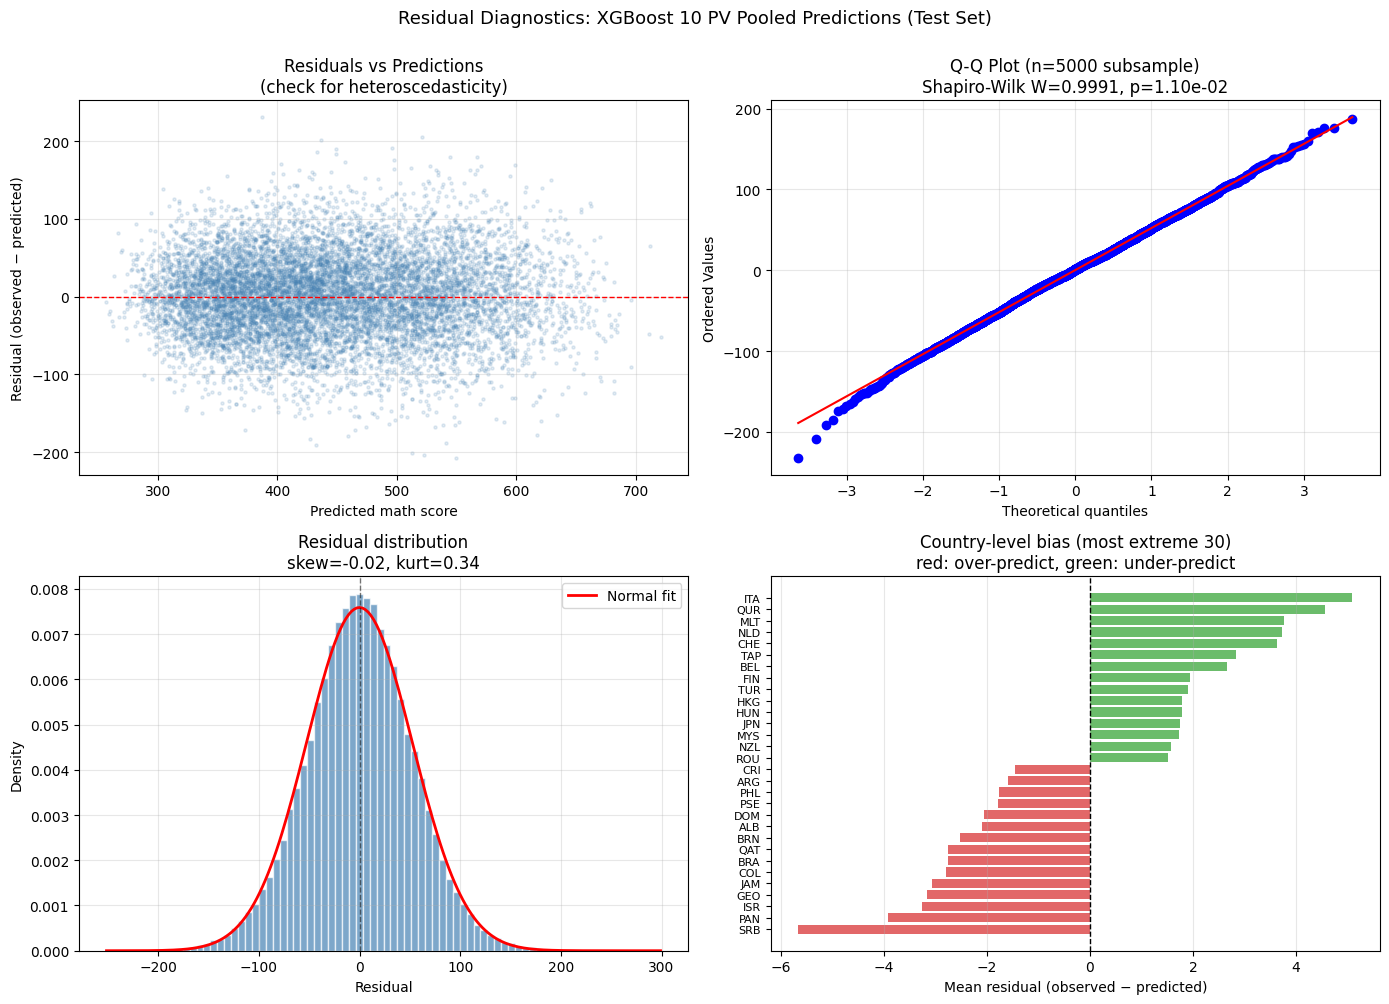


System memory: available = 5.77 GB


In [ ]:
# Residual diagnostics for the main XGBoost 10 PV model
# Purpose: Assess model validity assumptions and identify systematic bias patterns.
# Rationale:
#   - Although XGBoost doesn't require normality of residuals, systematic deviations
#     indicate unmodeled structure that could affect SHAP interpretation.
#   - Heteroscedasticity in residuals across predicted ranges may reveal that the model
#     performs differently for high vs low achievers.
#   - Country-level residual bias directly addresses (cross-national variability).

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Use pooled test predictions: mean of 10 PV models' predictions on test set
yhat_test_pooled = xgb_predictions_test.mean(axis=1)

# Use PV1MATH as the "observed" target for residual diagnostics (standard practice for
# residual plots; a single PV is used because residuals are PV-specific)
y_test_pv1 = Y_pvs_test[:, 0]

# Compute residuals (observed - predicted), using pooled predictions and PV1
residuals = y_test_pv1 - yhat_test_pooled

print("Residual diagnostics for pooled XGBoost predictions (test set)")
print(f"  Test sample size : {len(residuals):,}")
print(f"  Mean residual    : {residuals.mean():.3f}")
print(f"  Median residual  : {np.median(residuals):.3f}")
print(f"  Std of residuals : {residuals.std():.3f}")
print(f"  Min / Max        : {residuals.min():.2f} / {residuals.max():.2f}")
print(f"  Skewness         : {stats.skew(residuals):.3f}")
print(f"  Kurtosis (excess): {stats.kurtosis(residuals):.3f}")
print()

# 1. Normality check: Shapiro-Wilk on a subsample (test N > 5000 breaks SW)
# Shapiro-Wilk accurate up to ~5000; use a random subsample
subsample_size = 5000
np.random.seed(RANDOM_SEED)
sample_idx = np.random.choice(len(residuals), subsample_size, replace=False)
sw_stat, sw_pvalue = stats.shapiro(residuals[sample_idx])

print(f"Shapiro-Wilk normality test (n={subsample_size} subsample)")
print(f"  W statistic : {sw_stat:.4f}")
print(f"  p-value     : {sw_pvalue:.2e}")
if sw_pvalue < 0.001:
    print(f"  -> Normality rejected at alpha=0.001 (typical for large n; SW is highly sensitive).")
else:
    print(f"  -> Normality not rejected at alpha=0.001.")
print()

# 2. Heteroscedasticity check: Breusch-Pagan style test
# Regress squared residuals on predictions; large slope => heteroscedasticity
from sklearn.linear_model import LinearRegression
bp_model = LinearRegression().fit(yhat_test_pooled.reshape(-1, 1), residuals ** 2)
bp_slope = bp_model.coef_[0]
bp_intercept = bp_model.intercept_

# Correlation between |residual| and prediction
hetero_corr = np.corrcoef(yhat_test_pooled, np.abs(residuals))[0, 1]

print(f"Heteroscedasticity indicators")
print(f"  Slope of (residual² ~ prediction) : {bp_slope:.4f}")
print(f"  Pearson r (|residual| vs prediction) : {hetero_corr:.4f}")
if abs(hetero_corr) < 0.10:
    print(f"  -> Homoscedasticity approximately holds (|r| < 0.10).")
elif abs(hetero_corr) < 0.20:
    print(f"  -> Mild heteroscedasticity (0.10 <= |r| < 0.20).")
else:
    print(f"  -> Notable heteroscedasticity (|r| >= 0.20); residual spread varies across prediction range.")
print()

# 3. Country-level residual bias
test_df = pd.DataFrame({
    "CNT": ids_test["CNT"].values,
    "y_pv1": y_test_pv1,
    "yhat_pooled": yhat_test_pooled,
    "residual": residuals,
})

country_bias = test_df.groupby("CNT")["residual"].agg(["mean", "std", "count"]).reset_index()
country_bias.columns = ["CNT", "mean_residual", "std_residual", "n_students"]
country_bias = country_bias.sort_values("mean_residual")

print("Country-level residual bias")
print(f"  Number of countries            : {len(country_bias)}")
print(f"  Mean country-level bias        : {country_bias['mean_residual'].mean():.3f}")
print(f"  Std of country-level biases    : {country_bias['mean_residual'].std():.3f}")
print(f"  Min country bias (most under)  : {country_bias['mean_residual'].min():.2f} "
      f"({country_bias.iloc[0]['CNT']})")
print(f"  Max country bias (most over)   : {country_bias['mean_residual'].max():.2f} "
      f"({country_bias.iloc[-1]['CNT']})")
print()

print("Top 10 countries with most NEGATIVE bias (model OVER-predicts)")
print(country_bias.head(10).round(2).to_string(index=False))
print()

print("Top 10 countries with most POSITIVE bias (model UNDER-predicts)")
print(country_bias.tail(10).round(2).to_string(index=False))
print()

# 4. Diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Residual Diagnostics: XGBoost 10 PV Pooled Predictions (Test Set)",
             fontsize=13, y=1.00)

# Plot 1: Residuals vs predictions (heteroscedasticity check)
ax1 = axes[0, 0]
# Random subsample for plotting clarity
plot_idx = np.random.choice(len(residuals), min(10000, len(residuals)), replace=False)
ax1.scatter(yhat_test_pooled[plot_idx], residuals[plot_idx],
            alpha=0.15, s=5, color="steelblue", rasterized=True)
ax1.axhline(0, color="red", linestyle="--", linewidth=1)
ax1.set_xlabel("Predicted math score")
ax1.set_ylabel("Residual (observed − predicted)")
ax1.set_title("Residuals vs Predictions\n(check for heteroscedasticity)")
ax1.grid(alpha=0.3)

# Plot 2: Q-Q plot (normality check)
ax2 = axes[0, 1]
stats.probplot(residuals[sample_idx], dist="norm", plot=ax2)
ax2.set_title(f"Q-Q Plot (n={subsample_size} subsample)\n"
              f"Shapiro-Wilk W={sw_stat:.4f}, p={sw_pvalue:.2e}")
ax2.grid(alpha=0.3)

# Plot 3: Residual histogram
ax3 = axes[1, 0]
ax3.hist(residuals, bins=80, density=True, alpha=0.7, color="steelblue", edgecolor="white")
# Overlay normal distribution with same mean, std
x_range = np.linspace(residuals.min(), residuals.max(), 200)
ax3.plot(x_range, stats.norm.pdf(x_range, residuals.mean(), residuals.std()),
         color="red", linewidth=2, label="Normal fit")
ax3.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.5)
ax3.set_xlabel("Residual")
ax3.set_ylabel("Density")
ax3.set_title(f"Residual distribution\nskew={stats.skew(residuals):.2f}, "
              f"kurt={stats.kurtosis(residuals):.2f}")
ax3.legend()
ax3.grid(alpha=0.3)

# Plot 4: Country-level bias bar chart (top/bottom 15 countries)
ax4 = axes[1, 1]
top_15_under = country_bias.tail(15)  # positive bias = under-predict
bottom_15_over = country_bias.head(15)  # negative bias = over-predict
country_plot_data = pd.concat([bottom_15_over, top_15_under])
colors = ["#d62728"] * len(bottom_15_over) + ["#2ca02c"] * len(top_15_under)
y_pos = np.arange(len(country_plot_data))
ax4.barh(y_pos, country_plot_data["mean_residual"], color=colors, alpha=0.7)
ax4.set_yticks(y_pos)
ax4.set_yticklabels(country_plot_data["CNT"], fontsize=8)
ax4.axvline(0, color="black", linestyle="--", linewidth=1)
ax4.set_xlabel("Mean residual (observed − predicted)")
ax4.set_title("Country-level bias (most extreme 30)\nred: over-predict, green: under-predict")
ax4.grid(alpha=0.3, axis="x")

plt.tight_layout()

# Save figure
DIAGNOSTICS_DIR = PROJECT_ROOT / "data" / "analysis" / "diagnostics"
DIAGNOSTICS_DIR.mkdir(parents=True, exist_ok=True)
fig_path = DIAGNOSTICS_DIR / "residual_diagnostics.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Diagnostics figure saved: {fig_path.name}")

plt.show()

# 5. Store diagnostic artifacts
diagnostics_summary = {
    "mean_residual": float(residuals.mean()),
    "std_residual": float(residuals.std()),
    "skewness": float(stats.skew(residuals)),
    "kurtosis": float(stats.kurtosis(residuals)),
    "shapiro_wilk_W": float(sw_stat),
    "shapiro_wilk_pvalue": float(sw_pvalue),
    "heteroscedasticity_slope": float(bp_slope),
    "heteroscedasticity_corr": float(hetero_corr),
    "country_bias_mean": float(country_bias["mean_residual"].mean()),
    "country_bias_std": float(country_bias["mean_residual"].std()),
    "country_bias_min": float(country_bias["mean_residual"].min()),
    "country_bias_max": float(country_bias["mean_residual"].max()),
}

vm = psutil.virtual_memory()
print()
print(f"System memory: available = {vm.available / 1e9:.2f} GB")

Predicted-vs-actual figure saved: predicted_vs_actual.png


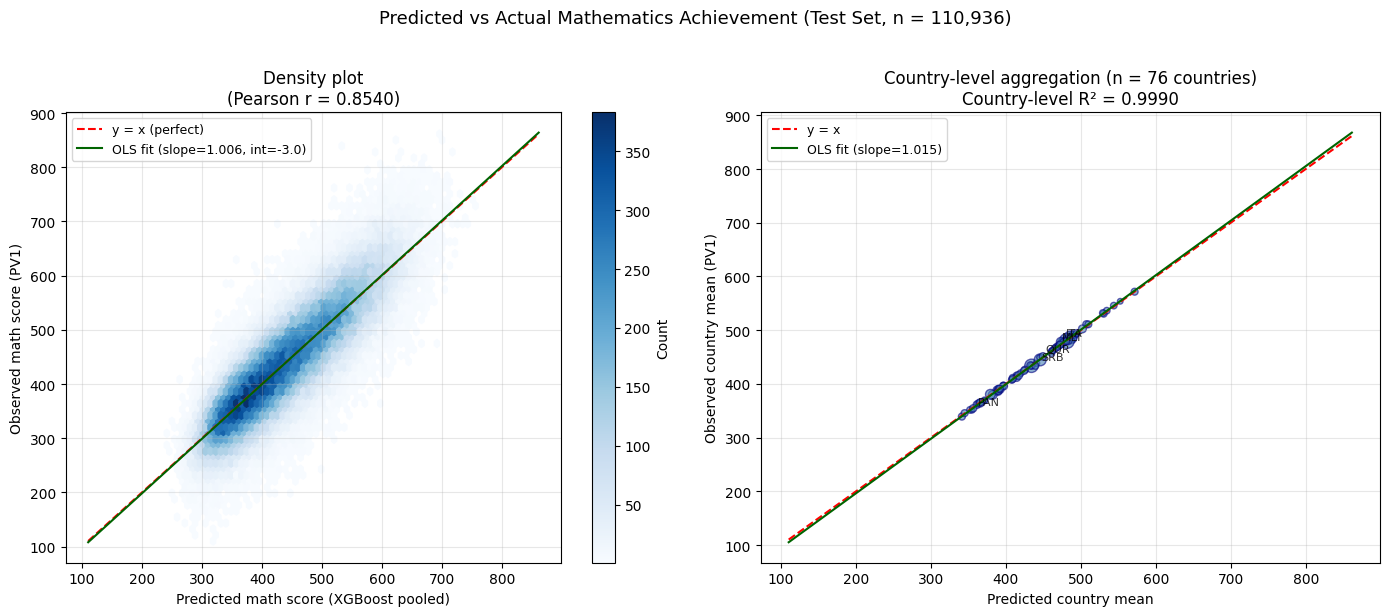


FINAL TEST SET PERFORMANCE REPORT (for thesis Results chapter)

                                Metric            Value
                      Test sample size          110,936
            Number of countries (test)               76
                        Pooled test R²           0.7279
                                95% CI [0.7265, 0.7293]
                      Pooled test RMSE            52.74
                                95% CI   [52.59, 52.90]
                       Pooled test MAE            41.56
                                95% CI   [41.42, 41.70]
         Country-level R² (aggregated)           0.9990
               Student-level Pearson r           0.8540
                         Mean residual           -0.117
                     Residual skewness           -0.018
            Residual kurtosis (excess)            0.337
Heteroscedasticity r (|resid| vs pred)           0.0953
              Country-level bias (std)             1.94

Thesis Results chapter summary (ready-

In [ ]:
# Prediction vs actual analysis + final test set report
# Purpose: Generate the main publication-ready plot (predicted vs actual) and consolidate
#          final performance metrics

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Predicted vs Actual Mathematics Achievement (Test Set, n = {:,})".format(
    len(y_test_pv1)), fontsize=13, y=1.02)

# Plot 1: Hexbin density (most informative for large n)
ax1 = axes[0]
hb = ax1.hexbin(yhat_test_pooled, y_test_pv1, gridsize=60, cmap="Blues", mincnt=1)
# Identity line
low = min(yhat_test_pooled.min(), y_test_pv1.min())
high = max(yhat_test_pooled.max(), y_test_pv1.max())
ax1.plot([low, high], [low, high], color="red", linestyle="--", linewidth=1.5, label="y = x (perfect)")
# Regression line (observed on predicted)
reg_model = LinearRegression().fit(yhat_test_pooled.reshape(-1, 1), y_test_pv1)
reg_line_x = np.linspace(low, high, 100)
reg_line_y = reg_model.predict(reg_line_x.reshape(-1, 1))
ax1.plot(reg_line_x, reg_line_y, color="darkgreen", linewidth=1.5,
         label=f"OLS fit (slope={reg_model.coef_[0]:.3f}, int={reg_model.intercept_:.1f})")
ax1.set_xlabel("Predicted math score (XGBoost pooled)")
ax1.set_ylabel("Observed math score (PV1)")
ax1.set_title(f"Density plot\n(Pearson r = {np.corrcoef(yhat_test_pooled, y_test_pv1)[0, 1]:.4f})")
ax1.legend(loc="upper left", fontsize=9)
cb = plt.colorbar(hb, ax=ax1, label="Count")
ax1.grid(alpha=0.3)

# Plot 2: Country-aggregated scatter (each point = one country's mean)
country_agg = test_df.groupby("CNT").agg(
    mean_obs=("y_pv1", "mean"),
    mean_pred=("yhat_pooled", "mean"),
    n=("y_pv1", "count"),
).reset_index()

ax2 = axes[1]
ax2.scatter(country_agg["mean_pred"], country_agg["mean_obs"],
            s=country_agg["n"] / 50, alpha=0.6, color="steelblue", edgecolor="navy")
ax2.plot([low, high], [low, high], color="red", linestyle="--", linewidth=1.5, label="y = x")

# Country-level OLS
country_reg = LinearRegression().fit(
    country_agg["mean_pred"].values.reshape(-1, 1),
    country_agg["mean_obs"].values,
)
reg_line_y_c = country_reg.predict(reg_line_x.reshape(-1, 1))
ax2.plot(reg_line_x, reg_line_y_c, color="darkgreen", linewidth=1.5,
         label=f"OLS fit (slope={country_reg.coef_[0]:.3f})")

# Label 5 most extreme countries
country_agg["abs_resid"] = np.abs(country_agg["mean_obs"] - country_agg["mean_pred"])
top_outliers = country_agg.nlargest(5, "abs_resid")
for _, row in top_outliers.iterrows():
    ax2.annotate(row["CNT"], (row["mean_pred"], row["mean_obs"]),
                 xytext=(4, 4), textcoords="offset points", fontsize=8, alpha=0.8)

country_r2 = country_reg.score(
    country_agg["mean_pred"].values.reshape(-1, 1),
    country_agg["mean_obs"].values,
)
ax2.set_xlabel("Predicted country mean")
ax2.set_ylabel("Observed country mean (PV1)")
ax2.set_title(f"Country-level aggregation (n = {len(country_agg)} countries)\n"
              f"Country-level R² = {country_r2:.4f}")
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
fig_path2 = DIAGNOSTICS_DIR / "predicted_vs_actual.png"
fig.savefig(fig_path2, dpi=150, bbox_inches="tight")
print(f"Predicted-vs-actual figure saved: {fig_path2.name}")
plt.show()

# Final consolidated test set report
print()
print("FINAL TEST SET PERFORMANCE REPORT")
print()

report_df = pd.DataFrame({
    "Metric": [
        "Test sample size",
        "Number of countries (test)",
        "Pooled test R²",
        "  95% CI",
        "Pooled test RMSE",
        "  95% CI",
        "Pooled test MAE",
        "  95% CI",
        "Country-level R² (aggregated)",
        "Student-level Pearson r",
        "Mean residual",
        "Residual skewness",
        "Residual kurtosis (excess)",
        "Heteroscedasticity r (|resid| vs pred)",
        "Country-level bias (std)",
    ],
    "Value": [
        f"{len(y_test_pv1):,}",
        f"{country_agg.shape[0]}",
        f"{xgb_pooled_results['test_R2']['estimate']:.4f}",
        f"[{xgb_pooled_results['test_R2']['CI_lower']:.4f}, "
        f"{xgb_pooled_results['test_R2']['CI_upper']:.4f}]",
        f"{xgb_pooled_results['test_RMSE']['estimate']:.2f}",
        f"[{xgb_pooled_results['test_RMSE']['CI_lower']:.2f}, "
        f"{xgb_pooled_results['test_RMSE']['CI_upper']:.2f}]",
        f"{xgb_pooled_results['test_MAE']['estimate']:.2f}",
        f"[{xgb_pooled_results['test_MAE']['CI_lower']:.2f}, "
        f"{xgb_pooled_results['test_MAE']['CI_upper']:.2f}]",
        f"{country_r2:.4f}",
        f"{np.corrcoef(yhat_test_pooled, y_test_pv1)[0, 1]:.4f}",
        f"{residuals.mean():.3f}",
        f"{stats.skew(residuals):.3f}",
        f"{stats.kurtosis(residuals):.3f}",
        f"{hetero_corr:.4f}",
        f"{country_bias['mean_residual'].std():.2f}",
    ],
})
print(report_df.to_string(index=False))
print()

# Store final report for artifact saving
final_report = {
    "test_n": int(len(y_test_pv1)),
    "n_countries_test": int(country_agg.shape[0]),
    "pooled_test_r2": float(xgb_pooled_results["test_R2"]["estimate"]),
    "pooled_test_r2_ci": [float(xgb_pooled_results["test_R2"]["CI_lower"]),
                         float(xgb_pooled_results["test_R2"]["CI_upper"])],
    "pooled_test_rmse": float(xgb_pooled_results["test_RMSE"]["estimate"]),
    "pooled_test_rmse_ci": [float(xgb_pooled_results["test_RMSE"]["CI_lower"]),
                           float(xgb_pooled_results["test_RMSE"]["CI_upper"])],
    "country_level_r2": float(country_r2),
    "country_level_ols_slope": float(country_reg.coef_[0]),
    "student_pearson_r": float(np.corrcoef(yhat_test_pooled, y_test_pv1)[0, 1]),
    "diagnostics": diagnostics_summary,
}

vm = psutil.virtual_memory()
print(f"System memory: available = {vm.available / 1e9:.2f} GB")

In [75]:
# Model ve predictions saving

import pickle

ARTIFACTS_DIR = PROJECT_ROOT / "data" / "analysis" / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# 10 XGBoost models as a single pickle
xgb_models_path = ARTIFACTS_DIR / "xgb_models_10pv.pkl"
with open(xgb_models_path, "wb") as f:
    pickle.dump({
        "models": xgb_models,
        "feature_names": feature_names,
        "locked_params": LOCKED_XGB_PARAMS,
        "n_pvs": 10,
    }, f)

print(f"Saved: {xgb_models_path.name}")
print(f"  Size: {xgb_models_path.stat().st_size / 1e6:.1f} MB")
print(f"  Contains: 10 XGBoost models + feature_names + locked_params")
print()

# Ridge models (from Cell 9-10)
ridge_models_path = ARTIFACTS_DIR / "ridge_models_10pv.pkl"
with open(ridge_models_path, "wb") as f:
    pickle.dump({
        "models": ridge_results["models"],
        "imputer": ridge_results["imputer"],
        "feature_names": feature_names,
        "n_pvs": 10,
    }, f)

print(f"Saved: {ridge_models_path.name}")
print(f"  Size: {ridge_models_path.stat().st_size / 1e6:.1f} MB")
print(f"  Contains: 10 Ridge Pipelines + MICE imputer")
print()

# Single model (math_score) from Sensitivity 1
single_model_path = ARTIFACTS_DIR / "xgb_single_model_mathscore.pkl"
with open(single_model_path, "wb") as f:
    pickle.dump({
        "model": sensitivity1_result["single_model"],
        "feature_names": feature_names,
        "locked_params": LOCKED_XGB_PARAMS,
    }, f)

print(f"Saved: {single_model_path.name}")
print(f"  Size: {single_model_path.stat().st_size / 1e6:.1f} MB")
print()

# Predictions: 10 PV XGBoost (train + test) as parquet
predictions_train_df = pd.DataFrame(
    xgb_predictions_train,
    columns=[f"pred_PV{i+1}MATH" for i in range(10)],
)
predictions_train_df["CNTSTUID"] = ids_train["CNTSTUID"].values
predictions_train_df["CNT"] = ids_train["CNT"].values
predictions_train_df = predictions_train_df[["CNTSTUID", "CNT"] + 
                                              [c for c in predictions_train_df.columns 
                                               if c.startswith("pred_")]]

predictions_test_df = pd.DataFrame(
    xgb_predictions_test,
    columns=[f"pred_PV{i+1}MATH" for i in range(10)],
)
predictions_test_df["CNTSTUID"] = ids_test["CNTSTUID"].values
predictions_test_df["CNT"] = ids_test["CNT"].values
predictions_test_df = predictions_test_df[["CNTSTUID", "CNT"] + 
                                            [c for c in predictions_test_df.columns 
                                             if c.startswith("pred_")]]

predictions_train_df.to_parquet(ARTIFACTS_DIR / "xgb_predictions_train_10pv.parquet", index=False)
predictions_test_df.to_parquet(ARTIFACTS_DIR / "xgb_predictions_test_10pv.parquet", index=False)

print(f"Saved: xgb_predictions_train_10pv.parquet  ({predictions_train_df.shape})")
print(f"Saved: xgb_predictions_test_10pv.parquet   ({predictions_test_df.shape})")
print()

# Ridge predictions
ridge_predictions_test_df = pd.DataFrame(
    ridge_results["predictions_test"],
    columns=[f"pred_PV{i+1}MATH" for i in range(10)],
)
ridge_predictions_test_df["CNTSTUID"] = ids_test["CNTSTUID"].values
ridge_predictions_test_df["CNT"] = ids_test["CNT"].values
ridge_predictions_test_df = ridge_predictions_test_df[["CNTSTUID", "CNT"] + 
                                                        [c for c in ridge_predictions_test_df.columns 
                                                         if c.startswith("pred_")]]
ridge_predictions_test_df.to_parquet(ARTIFACTS_DIR / "ridge_predictions_test_10pv.parquet", index=False)
print(f"Saved: ridge_predictions_test_10pv.parquet ({ridge_predictions_test_df.shape})")
print()

vm = psutil.virtual_memory()
print(f"System memory: available = {vm.available / 1e9:.2f} GB")

Saved: xgb_models_10pv.pkl
  Size: 676.1 MB
  Contains: 10 XGBoost models + feature_names + locked_params

Saved: ridge_models_10pv.pkl
  Size: 0.1 MB
  Contains: 10 Ridge Pipelines + MICE imputer

Saved: xgb_single_model_mathscore.pkl
  Size: 72.2 MB

Saved: xgb_predictions_train_10pv.parquet  ((443744, 12))
Saved: xgb_predictions_test_10pv.parquet   ((110936, 12))

Saved: ridge_predictions_test_10pv.parquet ((110936, 12))

System memory: available = 5.02 GB


In [77]:
# Feature importance, performance metrics, diagnostics saving

importance_summary.to_parquet(ARTIFACTS_DIR / "xgb_feature_importance_10pv.parquet", index=False)
print(f"Saved: xgb_feature_importance_10pv.parquet  ({importance_summary.shape})")

# Per-PV metrics for both Ridge and XGBoost
xgb_metrics_df.to_parquet(ARTIFACTS_DIR / "xgb_metrics_per_pv.parquet", index=False)
ridge_metrics_df = ridge_results["metrics_per_pv"].copy()
ridge_metrics_df.to_parquet(ARTIFACTS_DIR / "ridge_metrics_per_pv.parquet", index=False)
print(f"Saved: xgb_metrics_per_pv.parquet           ({xgb_metrics_df.shape})")
print(f"Saved: ridge_metrics_per_pv.parquet         ({ridge_metrics_df.shape})")
print()

# Consolidated pooled metrics + diagnostics as JSON
consolidated_report = {
    "xgb": {
        "pooled_metrics": {
            metric: {
                "estimate": float(xgb_pooled_results[metric]["estimate"]),
                "SE": float(xgb_pooled_results[metric]["SE"]),
                "CI_lower": float(xgb_pooled_results[metric]["CI_lower"]),
                "CI_upper": float(xgb_pooled_results[metric]["CI_upper"]),
                "between_var": float(xgb_pooled_results[metric]["between_var"]),
            }
            for metric in ["test_R2", "test_RMSE", "test_MAE", "overfit_gap"]
        },
        "per_pv_summary": {
            "test_R2_range": float(xgb_metrics_df["test_R2"].max() - xgb_metrics_df["test_R2"].min()),
            "test_RMSE_range": float(xgb_metrics_df["test_RMSE"].max() - xgb_metrics_df["test_RMSE"].min()),
            "best_iteration_mean": float(xgb_metrics_df["best_iteration"].mean()),
            "best_iteration_std": float(xgb_metrics_df["best_iteration"].std()),
        },
    },
    "ridge": {
        "pooled_metrics": {
            metric: {
                "estimate": float(pooled_results[metric]["estimate"]),
                "SE": float(pooled_results[metric]["SE"]),
                "CI_lower": float(pooled_results[metric]["CI_lower"]),
                "CI_upper": float(pooled_results[metric]["CI_upper"]),
                "between_var": float(pooled_results[metric]["between_var"]),
            }
            for metric in ["test_R2", "test_RMSE", "test_MAE"]
        },
    },
    "sensitivity_1_pv_averaging": {
        "single_model_r2": float(sensitivity1_result["single_model_r2"]),
        "single_model_rmse": float(sensitivity1_result["single_model_rmse"]),
        "single_model_mae": float(sensitivity1_result["single_model_mae"]),
        "pooled_r2": float(sensitivity1_result["pooled_r2"]),
        "pooled_rmse": float(sensitivity1_result["pooled_rmse"]),
        "r2_bias": float(abs(sensitivity1_result["pooled_r2"] - sensitivity1_result["single_model_r2"])),
        "rmse_bias": float(abs(sensitivity1_result["pooled_rmse"] - sensitivity1_result["single_model_rmse"])),
    },
    "sensitivity_2_ablation": {
        "reference_r2": float(sensitivity2_result["reference_r2"]),
        "reference_rmse": float(sensitivity2_result["reference_rmse"]),
        "without_system1_r2": float(sensitivity2_result["ablation_s1_r2"]),
        "without_system1_rmse": float(sensitivity2_result["ablation_s1_rmse"]),
        "without_nt15_r2": float(sensitivity2_result["ablation_nt15_r2"]),
        "without_nt15_rmse": float(sensitivity2_result["ablation_nt15_rmse"]),
        "drop_system1": float(sensitivity2_result["drop_s1"]),
        "drop_nt15": float(sensitivity2_result["drop_nt15"]),
        "ratio_s1_over_nt15": float(sensitivity2_result["drop_s1"] / sensitivity2_result["drop_nt15"])
                               if sensitivity2_result["drop_nt15"] > 0 else None,
    },
    "diagnostics": final_report,
    "data_split": {
        "train_n": int(X_train.shape[0]),
        "test_n": int(X_test.shape[0]),
        "n_features": int(X_train.shape[1]),
        "n_countries": int(ids_test["CNT"].nunique()),
        "random_seed": RANDOM_SEED,
    },
    "locked_hyperparameters": {
        k: (float(v) if isinstance(v, (np.floating, float)) 
            else int(v) if isinstance(v, (np.integer, int))
            else v)
        for k, v in LOCKED_XGB_PARAMS.items()
    },
}

import json
report_path = ARTIFACTS_DIR / "consolidated_report.json"
with open(report_path, "w") as f:
    json.dump(consolidated_report, f, indent=2)

print(f"Saved: {report_path.name}")
print(f"  Size: {report_path.stat().st_size / 1e3:.1f} KB")
print()

# Country-level bias table
country_bias.to_parquet(ARTIFACTS_DIR / "country_level_bias.parquet", index=False)
print(f"Saved: country_level_bias.parquet           ({country_bias.shape})")
print()

# Test set IDs + country (for 04 SHAP notebook's subgroup analysis)
test_metadata_df = ids_test.copy()
test_metadata_df["y_pv1"] = Y_pvs_test[:, 0]
test_metadata_df["yhat_pooled"] = yhat_test_pooled
test_metadata_df["residual"] = residuals
test_metadata_df.to_parquet(ARTIFACTS_DIR / "test_metadata.parquet", index=False)
print(f"Saved: test_metadata.parquet                ({test_metadata_df.shape})")
print()

# Artifact inventory
print("Artifact inventory for 04_shap_xai.ipynb")
print(f"{'File':<45s} {'Size':>10s}")
for f in sorted(ARTIFACTS_DIR.glob("*")):
    size_mb = f.stat().st_size / 1e6
    if size_mb >= 1:
        size_str = f"{size_mb:.1f} MB"
    else:
        size_str = f"{f.stat().st_size / 1e3:.1f} KB"
    print(f"{f.name:<45s} {size_str:>10s}")

vm = psutil.virtual_memory()
print()
print(f"System memory: available = {vm.available / 1e9:.2f} GB")

Saved: xgb_feature_importance_10pv.parquet  ((102, 12))
Saved: xgb_metrics_per_pv.parquet           ((10, 9))
Saved: ridge_metrics_per_pv.parquet         ((10, 6))

Saved: consolidated_report.json
  Size: 4.3 KB

Saved: country_level_bias.parquet           ((76, 4))

Saved: test_metadata.parquet                ((110936, 6))

Artifact inventory for 04_shap_xai.ipynb
File                                                Size
consolidated_report.json                          4.3 KB
country_level_bias.parquet                        4.5 KB
ridge_metrics_per_pv.parquet                      4.4 KB
ridge_models_10pv.pkl                           118.1 KB
ridge_predictions_test_10pv.parquet               7.5 MB
test_metadata.parquet                             3.1 MB
xgb_feature_importance_10pv.parquet              17.1 KB
xgb_metrics_per_pv.parquet                        6.4 KB
xgb_models_10pv.pkl                             676.1 MB
xgb_predictions_test_10pv.parquet                 7.6 MB
xgb_p